In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colorbar as colorbar
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import torch.utils.benchmark as benchmark
from icl.figures.task_vec_viz import *
from tqdm.notebook import tqdm, trange
import os

import plotly.io as pio
pio.renderers.default = "notebook_connected"
import plotly.graph_objects as go

import copy

from icl.utils.train import train_model_with_plot
from icl.latent_markov import * # import the latent markov task and its configuration
from icl.models import Transformer
from icl.figures.attn_plots_beta import visualize_attention
from icl.utils.train_utils import get_attn_base, compute_cross_entropy, ih_score, get_attn_at_layer_base
from icl.figures.head_view import *
from icl.utils.latent_task_vec import *
from icl.utils.markov_conditional_sampler import *
from icl.utils.simple_markov_sampler import get_all_samples_base_only
import icl.utils.notebook_utils as nu
from icl.utils.ultra_latent_task_vec import compute_hiddens_onepos_all_layers_ultra
from icl.utils.kv_latent_task_vec_beta import compute_hiddens_onepos_all_layers_kvcache_beta
from icl.utils.latent_ood_analysis import process_latent_ood_evolve_checkpoints
from icl.utils.unified_interface import get_exp_name, unified_train
from icl.utils.unified_plot import get_var_plot, projection_plot, traj_projection_plot
from icl.utils.unified_ood_analysis import (
    process_ood_minor_metric, 
    plot_training_curves_all_experiments, 
    plot_training_curves_all_experiments_mpl
)
from icl.utils.attention_scores import (
    get_attention_score_at_step, 
    get_attn_map
)
from icl.utils.attn_plots import (
    plot_attention_scores_over_steps, 
    visualize_attention_with_head_view, 
    plot_max_scores_over_k_steps,
)
from icl.utils.attn_plots_mpl import (
    plot_attention_scores_over_steps_mpl,
    plot_max_scores_over_k_steps_mpl,
)
from icl.utils.intervention import random_injection_latent_padded_only, plot_injection_results
from icl.utils.historical_intervention import historical_injection_latent, plot_historical_injection_results
from icl.utils.projection_removal_intervention import projection_removal_latent_padded_only, plot_projection_removal_results

torch.set_printoptions(precision=3, sci_mode=False)

%load_ext autoreload
%autoreload 2

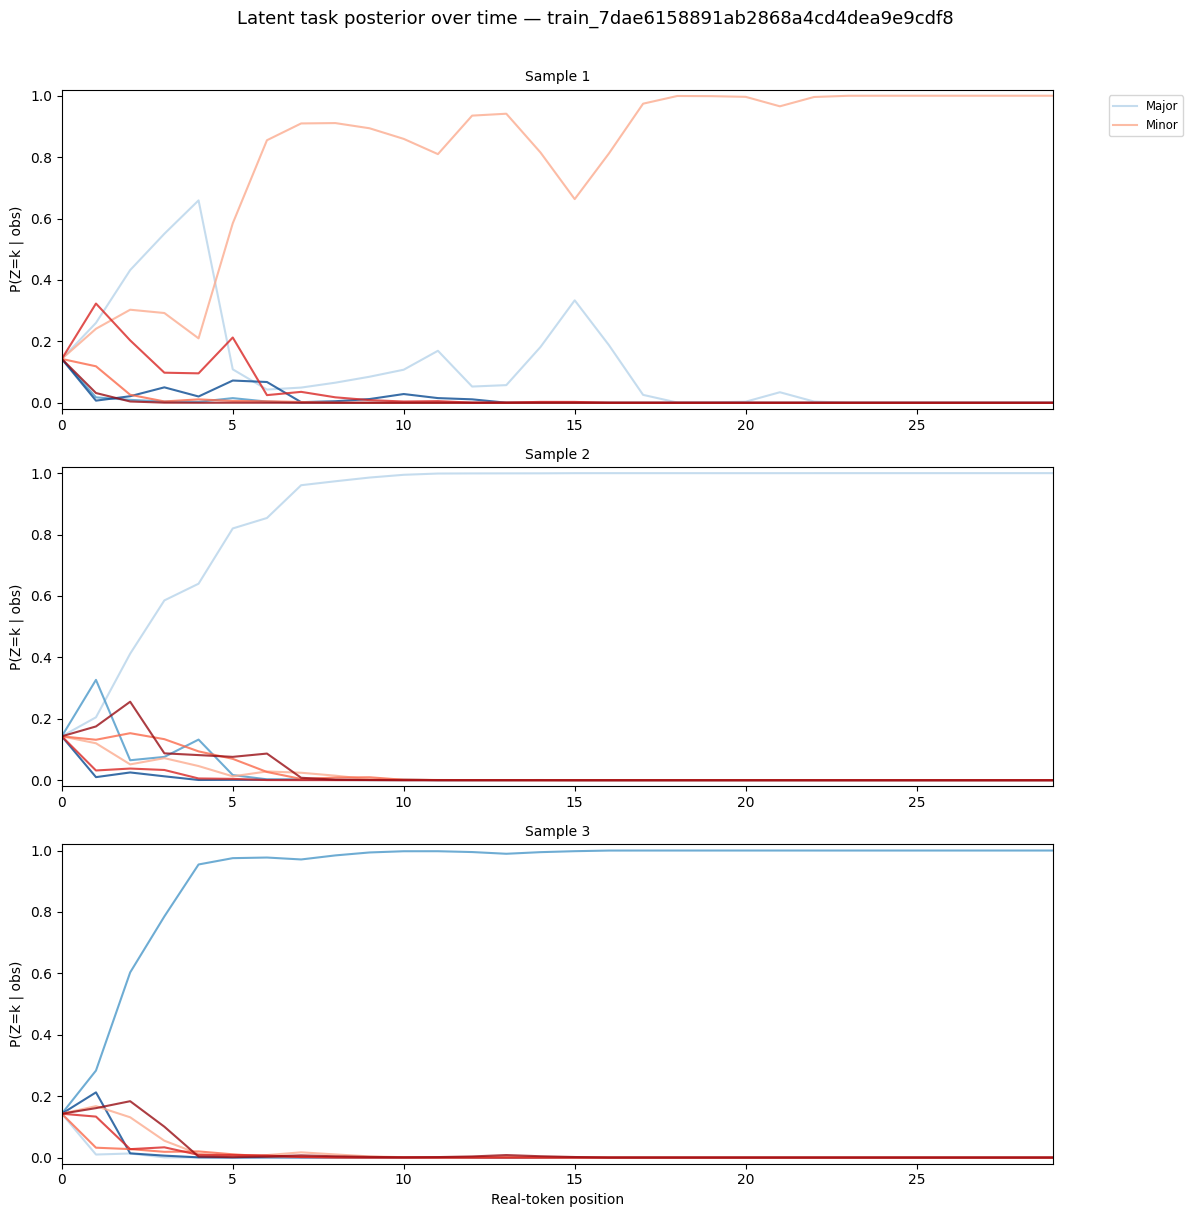

In [4]:
from icl.utils.unified_interface import plot_latent_task_posterior

exp_name = get_exp_name("latent", k=2, vocab_size=6)
info = plot_latent_task_posterior(exp_name, max_positions=30)

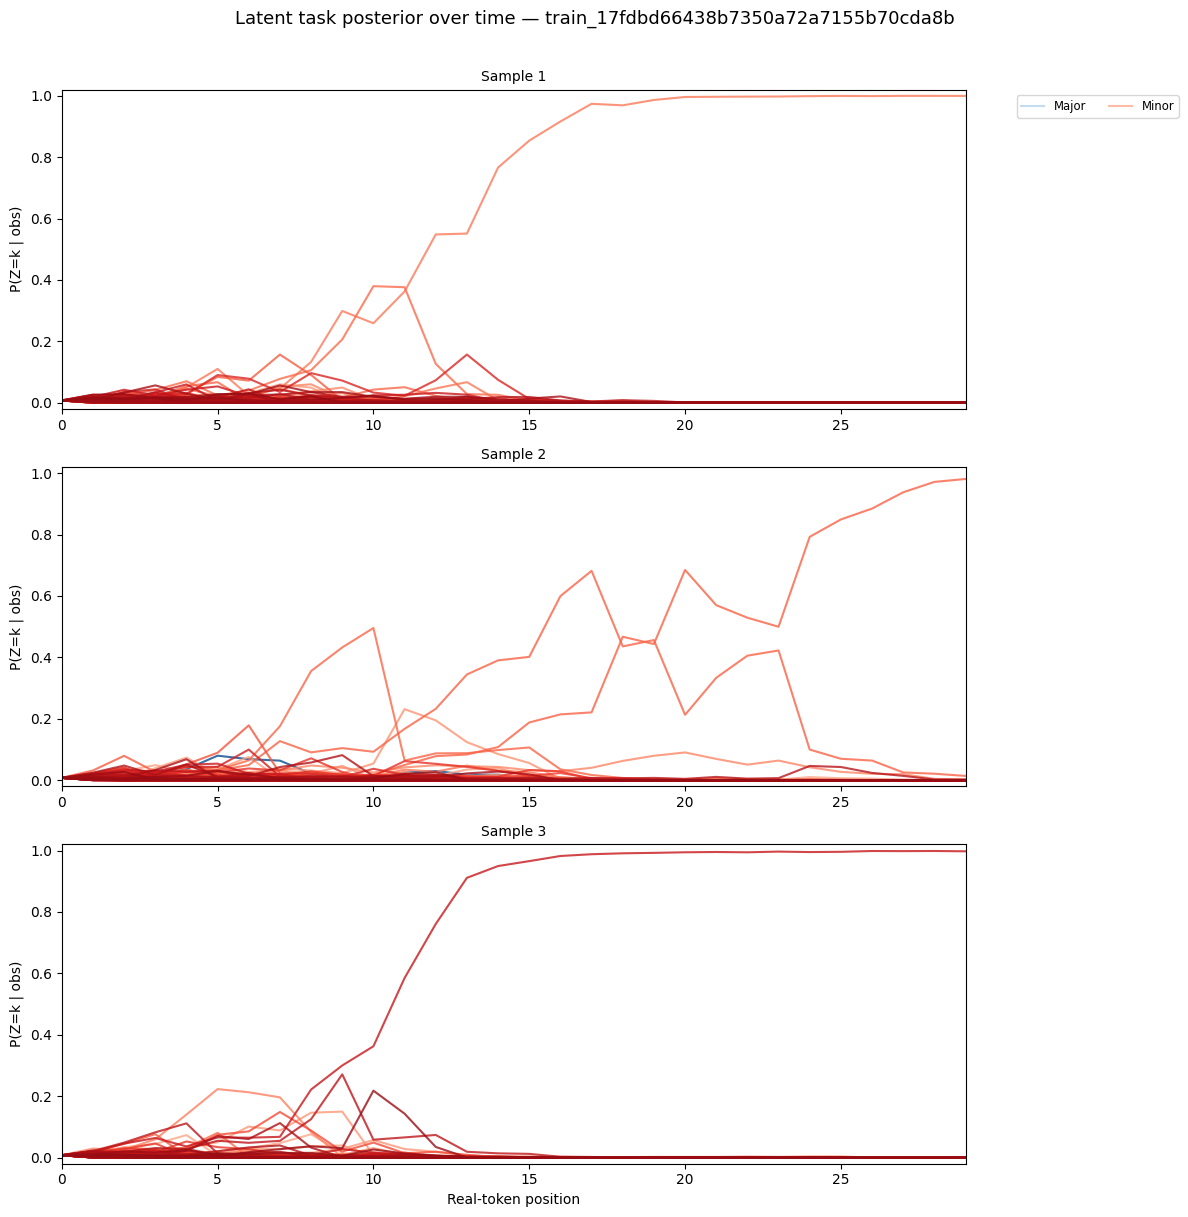

In [5]:
from icl.utils.unified_interface import plot_latent_task_posterior

exp_name = get_exp_name("latent", k=7, vocab_size=6)
info = plot_latent_task_posterior(exp_name, max_positions=30)

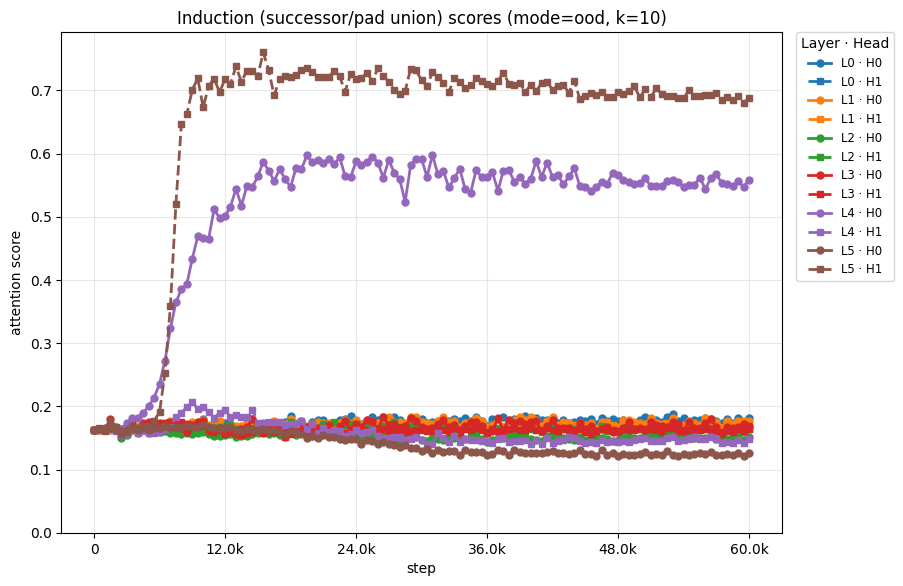

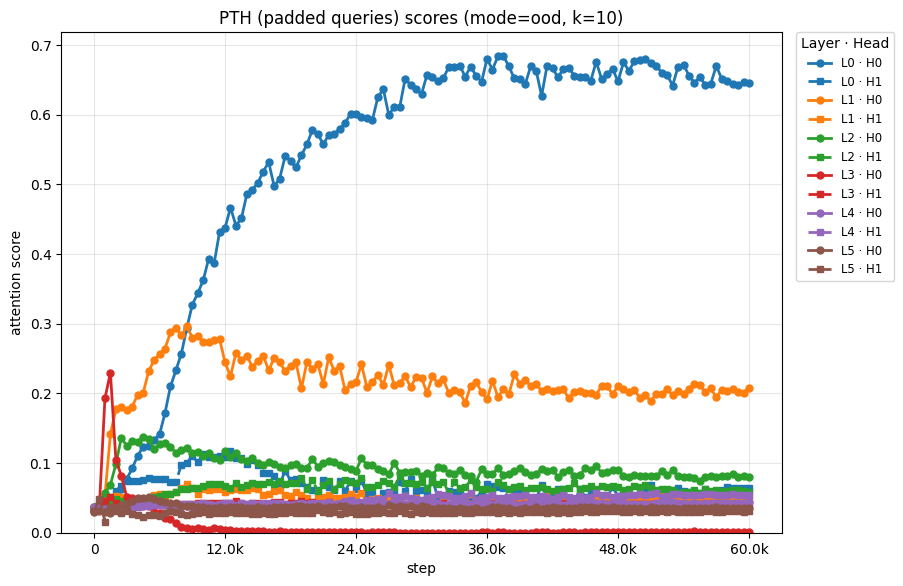

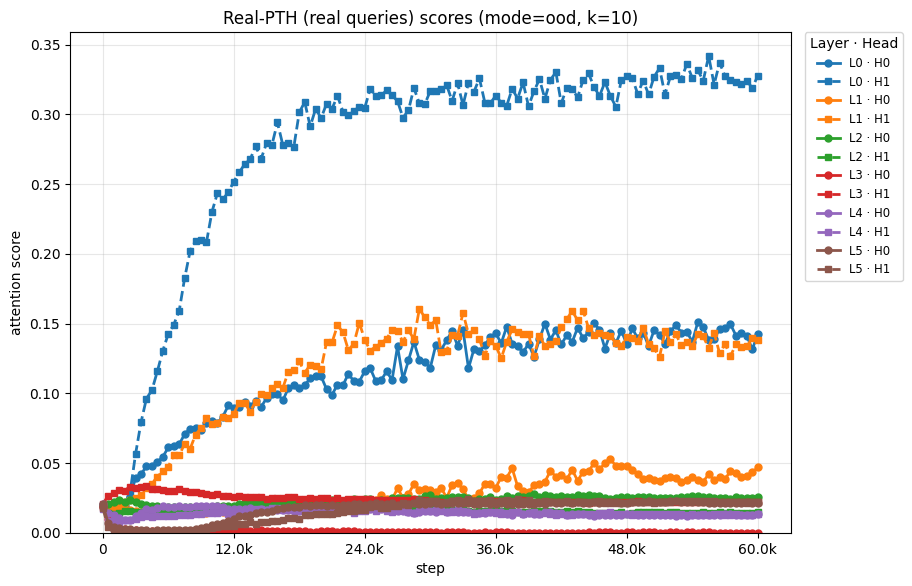

In [42]:
figs = plot_attention_scores_over_steps_mpl(
    k=10,
    steps=list(range(0, 60001, 500)),
    mode="ood",
    force_recompute=False,
)

In [9]:
for k in [1]:
    results = unified_train("latent", k=k, vocab_size=6)

wandb: Currently logged in as: hyan84 (hyan84-university-of-wisconsin-madison) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


2026-02-06 19:51:25 - icl.utils.train - INFO - Saving final model...


INFO:icl.utils.train:Saving final model...


Loss plots saved at ..\results\latent\train_0f84be6c8f8c07e90f62242aa3a0eee9\plots
..\results\latent\train_0f84be6c8f8c07e90f62242aa3a0eee9\plots\loss.png


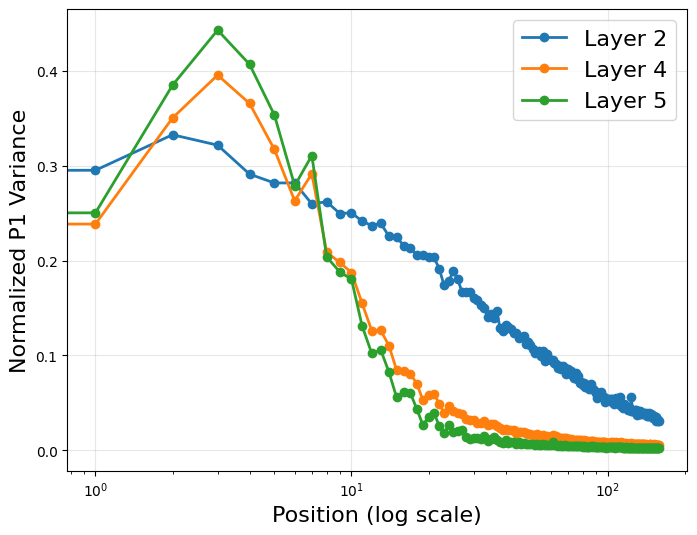

In [4]:
from icl.utils.unified_interface import get_exp_name, get_token_conditioned_hiddens_latent
from icl.linear.p1_variance import compute_p1_variance_multi_layer, extract_plotting_data_multi_layer
import matplotlib.pyplot as plt

# Get experiment name
exp_name = get_exp_name("latent", -1, vocab_size=6)

# Get token-conditioned hiddens
all_hiddens, token_info = get_token_conditioned_hiddens_latent(
    exp_name,
    layers=[2, 4, 5],
    batch_size=16,
    n_minor=0,
    n_ood=0,
    positions_of_interest=None,
)

# Compute P1 variance (same function as linear task!)
results_dict = compute_p1_variance_multi_layer(
    all_hiddens=all_hiddens,
    token_info=token_info,
    layers=[2, 4, 5],
)

# Extract plotting data
plotting_data = extract_plotting_data_multi_layer(results_dict)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
for layer_idx in plotting_data['layers']:
    positions = plotting_data['positions']
    var_pos_norm = plotting_data['var_pos_norm'][layer_idx]
    ax.plot(positions, var_pos_norm, 'o-', label=f'Layer {layer_idx}',
            linewidth=2, markersize=6)
ax.set_xlabel('Position (log scale)', fontsize=16)
ax.set_ylabel('Normalized P1 Variance', fontsize=16)
ax.set_xscale('log')
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
plt.show()

2026-02-06 18:25:58 - icl.utils.unified_interface - INFO - Inferred task_name: latent
2026-02-06 18:25:58 - icl.utils.unified_interface - INFO - Collecting hiddens for exp_name: train_3cbbc48ffa8b75fbc9f0bf106b881856, task_name: latent
2026-02-06 18:25:58 - icl.utils.unified_interface - INFO - Using n_minor=1000000 and n_ood=0
2026-02-06 18:25:58 - icl.utils.unified_interface - INFO - Computing hiddens using coin-style approach...
2026-02-06 18:25:58 - icl.utils.unified_interface - INFO - Retrieved hiddens with shape: torch.Size([6, 4, 160, 64, 128])
2026-02-06 18:25:58 - icl.utils.unified_interface - INFO - Number of minor tasks used: 1
2026-02-06 18:26:13 - icl.utils.unified_interface - INFO - Computed stable ranks with shape: torch.Size([6, 160])


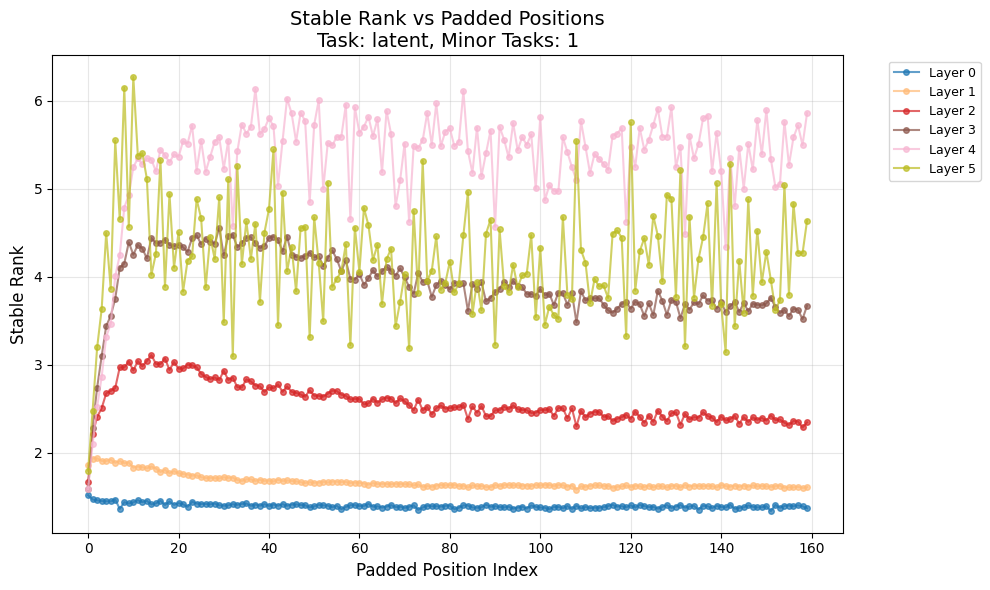

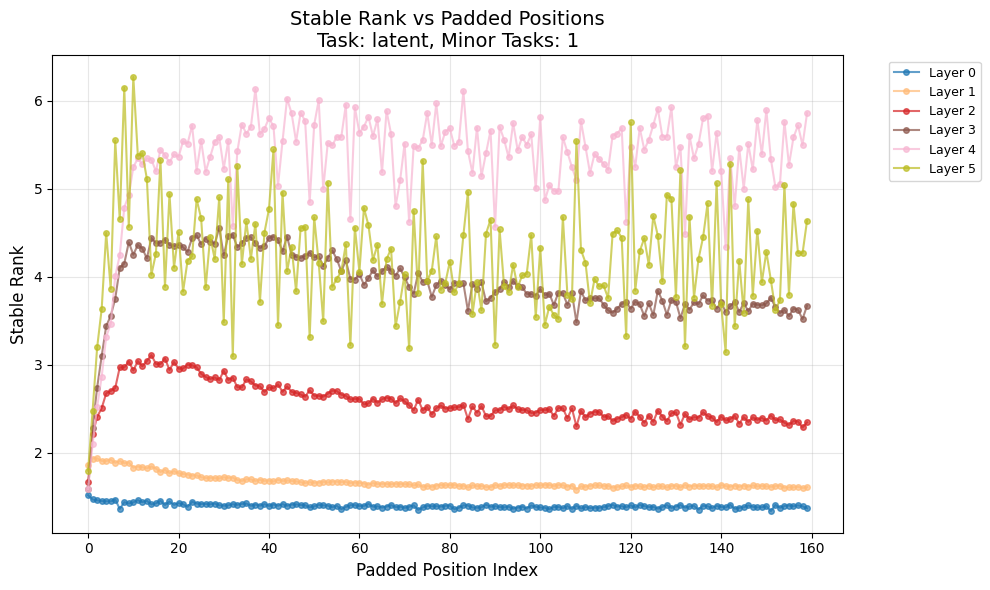

In [4]:
from icl.utils.unified_interface import compute_stable_rank_at_padded_positions, plot_stable_rank_vs_positions

exp_name = get_exp_name("latent", 0, vocab_size=6)
# Simple usage - auto-detects task type
results = compute_stable_rank_at_padded_positions(
    exp_name=exp_name,
    verbose=True
)


plot_stable_rank_vs_positions(
    results=results,
    layers=None,  # Plot all layers
    average_layers=False,  # Plot individual layers
    backend="matplotlib",
    show=True
)

2026-02-06 20:18:07 - icl.utils.unified_interface - INFO - Computing stable ranks for 11 different k values
2026-02-06 20:18:07 - icl.utils.unified_interface - INFO - Final layer index: 5
2026-02-06 20:18:07 - icl.utils.unified_interface - INFO - Processing in chunks of 2 k values
2026-02-06 20:18:07 - icl.utils.unified_interface - INFO - Processing chunk 1/6: k values range(0, 2)
2026-02-06 20:18:07 - icl.utils.unified_interface - INFO - Processing k=0 (n_tasks=1)...
2026-02-06 20:18:07 - icl.utils.unified_interface - INFO - Collecting hiddens for exp_name: train_3cbbc48ffa8b75fbc9f0bf106b881856, task_name: latent
2026-02-06 20:18:07 - icl.utils.unified_interface - INFO - Using n_minor=1 and n_ood=0
2026-02-06 20:18:08 - icl.utils.unified_interface - INFO - Computing hiddens using coin-style approach...
2026-02-06 20:18:08 - icl.utils.unified_interface - INFO - Retrieved hiddens with shape: torch.Size([6, 4, 160, 96, 128])
2026-02-06 20:18:08 - icl.utils.unified_interface - INFO - Num

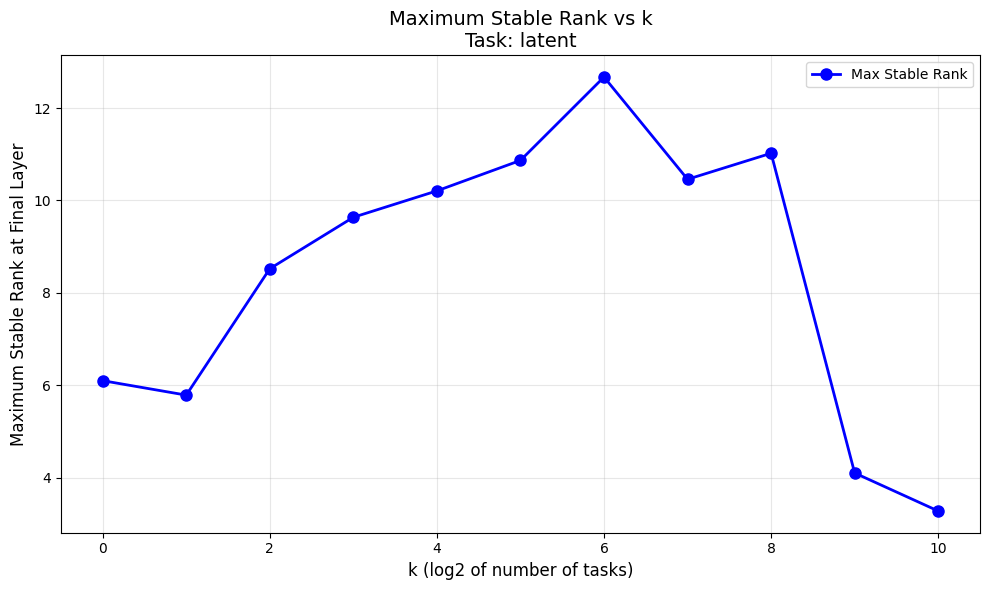

Max stable ranks: [6.100142955780029, 5.78724479675293, 8.522891998291016, 9.63607406616211, 10.207618713378906, 10.867033004760742, 12.671340942382812, 10.458239555358887, 11.021818161010742, 4.10155725479126, 3.2788915634155273]


In [3]:
from icl.utils.unified_interface import plot_max_stable_rank_vs_k

# Plot max stable rank vs k for different numbers of tasks
results = plot_max_stable_rank_vs_k(
    task_name="latent",
    k_values=range(11),  # k=-1 means no minor tasks
    vocab_size=6,
    B=96,
    verbose=True
)

# Access results
print(f"Max stable ranks: {results['max_stable_ranks']}")

2026-02-07 15:41:17 - icl.utils.unified_interface - INFO - Modified p_minor from 0.100000 to 0.842105 for uniform task sampling
2026-02-07 15:41:17 - icl.utils.unified_interface - INFO - Training linear softmax model to predict posteriors from layer 5 hidden representations
2026-02-07 15:41:17 - icl.utils.unified_interface - INFO - Number of tasks: 19 (major: 3, minor: 16), Batch size: 64, Total samples: 20000
2026-02-07 15:41:17 - icl.utils.unified_interface - INFO - Using positions: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19] (real token indices)
2026-02-07 15:41:17 - icl.utils.unified_interface - INFO - Collecting 313 batches of data...
2026-02-07 15:41:41 - icl.utils.unified_interface - INFO - Total data: 360576 samples
2026-02-07 15:41:41 - icl.utils.unified_interface - INFO - Training data: 288460 samples (80.0%)
2026-02-07 15:41:41 - icl.utils.unified_interface - INFO - Validation data: 72116 samples (20.0%)
2026-02-07 15:41:41 - icl.utils.unified_interface 

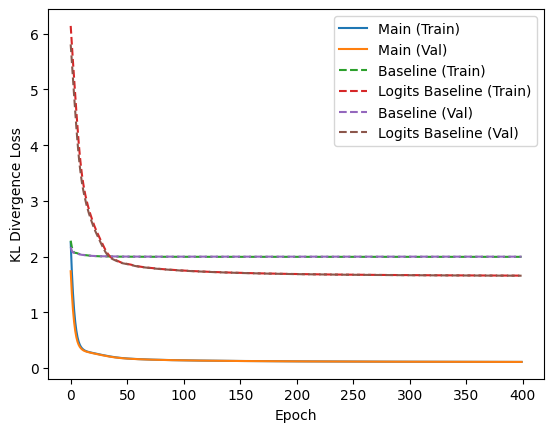

In [45]:
from icl.utils.unified_interface import train_linear_softmax_posterior_predictor

exp_name = get_exp_name("latent", 4, vocab_size=6)
results = train_linear_softmax_posterior_predictor(
    exp_name=exp_name,
    layer=5,
    n_samples=20000,
    validation_split=0.2,  # Use 20% for validation
    verbose=True,
    num_epochs=400,
    positions=range(2, 20)
)

print(f"Main model - Train: {results['final_loss']:.6f}, Val: {results['final_val_loss']:.6f}")
print(f"Logits baseline - Train: {results['logits_baseline_final_loss']:.6f}, Val: {results['logits_baseline_final_val_loss']:.6f}")
print(f"Baseline (shuffled) - Train: {results['baseline_final_loss']:.6f}, Val: {results['baseline_final_val_loss']:.6f}")

# Plot comparison
import matplotlib.pyplot as plt
plt.plot(results['loss_history'], label='Main (Train)')
plt.plot(results['val_loss_history'], label='Main (Val)')
plt.plot(results['baseline_loss_history'], label='Baseline (Train)', linestyle='--')
plt.plot(results['logits_baseline_loss_history'], label='Logits Baseline (Train)', linestyle='--')
plt.plot(results['baseline_val_loss_history'], label='Baseline (Val)', linestyle='--')
plt.plot(results['logits_baseline_val_loss_history'], label='Logits Baseline (Val)', linestyle='--')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('KL Divergence Loss')
plt.show()

In [38]:
from icl.utils.unified_interface import train_linear_hidden_predictor, get_exp_name

exp_name = get_exp_name("latent", 0, vocab_size=6)
results = train_linear_hidden_predictor(
    exp_name=exp_name,
    layer=1,
    n_samples=5000,
    validation_split=0.2,
    verbose=False,
    positions=range(5, 35),
)

# --- Print all baselines ---
print("\n=== Results Summary ===")
print(f"{'Model':<25} {'Train MSE':>12} {'Val MSE':>12} {'Train R²':>12} {'Val R²':>12}")
print("-" * 73)
print(f"{'Main (posterior logits)':<25} {results['train_mse']:>12.6f} {results['val_mse']:>12.6f} {results['train_r2']:>12.6f} {results['val_r2']:>12.6f}")
print(f"{'Permutation (shuffled)':<25} {results['baseline_train_mse']:>12.6f} {results['baseline_val_mse']:>12.6f} {results['baseline_train_r2']:>12.6f} {results['baseline_val_r2']:>12.6f}")
print(f"{'Logits baseline':<25} {results['logits_baseline_train_mse']:>12.6f} {results['logits_baseline_val_mse']:>12.6f} {results['logits_baseline_train_r2']:>12.6f} {results['logits_baseline_val_r2']:>12.6f}")
print(f"{'One-hot baseline':<25} {results['onehot_baseline_train_mse']:>12.6f} {results['onehot_baseline_val_mse']:>12.6f} {results['onehot_baseline_train_r2']:>12.6f} {results['onehot_baseline_val_r2']:>12.6f}")
print(f"{'Combined (all three)':<25} {results['combined_train_mse']:>12.6f} {results['combined_val_mse']:>12.6f} {results['combined_train_r2']:>12.6f} {results['combined_val_r2']:>12.6f}")

# --- Check if R² values are roughly additive (a sign of orthogonality) ---
sum_r2 = results['val_r2'] + results['logits_baseline_val_r2'] + results['onehot_baseline_val_r2']
print(f"\nSum of individual Val R²: {sum_r2:.6f}")
print(f"Combined Val R²:         {results['combined_val_r2']:.6f}")
print(f"Difference:              {results['combined_val_r2'] - sum_r2:.6f}  (near 0 = orthogonal)")

# --- Orthogonality analysis ---
ortho = results['orthogonality']
if ortho is not None:
    print("\n=== Orthogonality Analysis (centered val predictions) ===")
    print(f"\n{'Cosine sim (flat)':<25} {'Main':>10} {'Logits':>10} {'One-hot':>10}")
    print(f"{'Main':<25} {'---':>10} {ortho['cos_main_logits']:>10.4f} {ortho['cos_main_onehot']:>10.4f}")
    print(f"{'Logits':<25} {ortho['cos_main_logits']:>10.4f} {'---':>10} {ortho['cos_logits_onehot']:>10.4f}")
    print(f"{'One-hot':<25} {ortho['cos_main_onehot']:>10.4f} {ortho['cos_logits_onehot']:>10.4f} {'---':>10}")

    print(f"\n{'Cross R²':<25} {'from Main':>10} {'from Logits':>11} {'from One-hot':>12}")
    print(f"{'Main':<25} {'---':>10} {ortho['cross_r2_main_from_logits']:>11.4f} {ortho['cross_r2_main_from_onehot']:>12.4f}")
    print(f"{'Logits':<25} {ortho['cross_r2_logits_from_main']:>10.4f} {'---':>11} {ortho['cross_r2_logits_from_onehot']:>12.4f}")
    print(f"{'One-hot':<25} {ortho['cross_r2_onehot_from_main']:>10.4f} {ortho['cross_r2_onehot_from_logits']:>11.4f} {'---':>12}")


=== Results Summary ===
Model                        Train MSE      Val MSE     Train R²       Val R²
-------------------------------------------------------------------------
Main (posterior logits)       0.564661     0.563264     0.083844     0.083885
Permutation (shuffled)        0.616327     0.614882     0.000016    -0.000068
Logits baseline               0.446495     0.447127     0.275566     0.272776
One-hot baseline              0.110446     0.109710     0.820803     0.821563
Combined (all three)          0.320140     0.320769     0.480577     0.478288

Sum of individual Val R²: 1.178224
Combined Val R²:         0.478288
Difference:              -0.699935  (near 0 = orthogonal)

=== Orthogonality Analysis (centered val predictions) ===

Cosine sim (flat)               Main     Logits    One-hot
Main                             ---     0.1357     0.1655
Logits                        0.1357        ---     0.5450
One-hot                       0.1655     0.5450        ---

Cross R²

In [44]:
from icl.utils.unified_interface import train_linear_hidden_predictor, get_exp_name

exp_name = get_exp_name("latent", 0, vocab_size=6)
results = train_linear_hidden_predictor(
    exp_name=exp_name,
    layer=3,
    n_samples=5000,
    validation_split=0.2,
    verbose=False,
    positions=range(5, 35),
)

# --- Print all baselines ---
print("\n=== Results Summary ===")
print(f"{'Model':<25} {'Train MSE':>12} {'Val MSE':>12} {'Train R²':>12} {'Val R²':>12}")
print("-" * 73)
print(f"{'Main (posterior logits)':<25} {results['train_mse']:>12.6f} {results['val_mse']:>12.6f} {results['train_r2']:>12.6f} {results['val_r2']:>12.6f}")
print(f"{'Permutation (shuffled)':<25} {results['baseline_train_mse']:>12.6f} {results['baseline_val_mse']:>12.6f} {results['baseline_train_r2']:>12.6f} {results['baseline_val_r2']:>12.6f}")
print(f"{'Logits baseline':<25} {results['logits_baseline_train_mse']:>12.6f} {results['logits_baseline_val_mse']:>12.6f} {results['logits_baseline_train_r2']:>12.6f} {results['logits_baseline_val_r2']:>12.6f}")
print(f"{'One-hot baseline':<25} {results['onehot_baseline_train_mse']:>12.6f} {results['onehot_baseline_val_mse']:>12.6f} {results['onehot_baseline_train_r2']:>12.6f} {results['onehot_baseline_val_r2']:>12.6f}")
print(f"{'Combined (all three)':<25} {results['combined_train_mse']:>12.6f} {results['combined_val_mse']:>12.6f} {results['combined_train_r2']:>12.6f} {results['combined_val_r2']:>12.6f}")

# --- Check if R² values are roughly additive (a sign of orthogonality) ---
sum_r2 = results['val_r2'] + results['logits_baseline_val_r2'] + results['onehot_baseline_val_r2']
print(f"\nSum of individual Val R²: {sum_r2:.6f}")
print(f"Combined Val R²:         {results['combined_val_r2']:.6f}")
print(f"Difference:              {results['combined_val_r2'] - sum_r2:.6f}  (near 0 = orthogonal)")

# --- Orthogonality analysis ---
ortho = results['orthogonality']
if ortho is not None:
    print("\n=== Orthogonality Analysis (centered val predictions) ===")
    print(f"\n{'Cosine sim (flat)':<25} {'Main':>10} {'Logits':>10} {'One-hot':>10}")
    print(f"{'Main':<25} {'---':>10} {ortho['cos_main_logits']:>10.4f} {ortho['cos_main_onehot']:>10.4f}")
    print(f"{'Logits':<25} {ortho['cos_main_logits']:>10.4f} {'---':>10} {ortho['cos_logits_onehot']:>10.4f}")
    print(f"{'One-hot':<25} {ortho['cos_main_onehot']:>10.4f} {ortho['cos_logits_onehot']:>10.4f} {'---':>10}")

    print(f"\n{'Cross R²':<25} {'from Main':>10} {'from Logits':>11} {'from One-hot':>12}")
    print(f"{'Main':<25} {'---':>10} {ortho['cross_r2_main_from_logits']:>11.4f} {ortho['cross_r2_main_from_onehot']:>12.4f}")
    print(f"{'Logits':<25} {ortho['cross_r2_logits_from_main']:>10.4f} {'---':>11} {ortho['cross_r2_logits_from_onehot']:>12.4f}")
    print(f"{'One-hot':<25} {ortho['cross_r2_onehot_from_main']:>10.4f} {ortho['cross_r2_onehot_from_logits']:>11.4f} {'---':>12}")


=== Results Summary ===
Model                        Train MSE      Val MSE     Train R²       Val R²
-------------------------------------------------------------------------
Main (posterior logits)       0.842629     0.840764     0.477096     0.478283
Permutation (shuffled)        1.611399     1.611616     0.000026    -0.000052
Logits baseline               1.148986     1.149021     0.286982     0.287001
One-hot baseline              1.051044     1.049877     0.347761     0.348522
Combined (all three)          0.580121     0.578091     0.639998     0.641279

Sum of individual Val R²: 1.113806
Combined Val R²:         0.641279
Difference:              -0.472527  (near 0 = orthogonal)

=== Orthogonality Analysis (centered val predictions) ===

Cosine sim (flat)               Main     Logits    One-hot
Main                             ---     0.4242     0.1276
Logits                        0.4242        ---     0.3751
One-hot                       0.1276     0.3751        ---

Cross R²

In [42]:
from icl.utils.unified_interface import train_linear_hidden_predictor, get_exp_name

exp_name = get_exp_name("latent", 0, vocab_size=6)
results = train_linear_hidden_predictor(
    exp_name=exp_name,
    layer=5,
    n_samples=5000,
    validation_split=0.2,
    verbose=False,
    positions=range(5, 35),
)

# --- Print all baselines ---
print("\n=== Results Summary ===")
print(f"{'Model':<25} {'Train MSE':>12} {'Val MSE':>12} {'Train R²':>12} {'Val R²':>12}")
print("-" * 73)
print(f"{'Main (posterior logits)':<25} {results['train_mse']:>12.6f} {results['val_mse']:>12.6f} {results['train_r2']:>12.6f} {results['val_r2']:>12.6f}")
print(f"{'Permutation (shuffled)':<25} {results['baseline_train_mse']:>12.6f} {results['baseline_val_mse']:>12.6f} {results['baseline_train_r2']:>12.6f} {results['baseline_val_r2']:>12.6f}")
print(f"{'Logits baseline':<25} {results['logits_baseline_train_mse']:>12.6f} {results['logits_baseline_val_mse']:>12.6f} {results['logits_baseline_train_r2']:>12.6f} {results['logits_baseline_val_r2']:>12.6f}")
print(f"{'One-hot baseline':<25} {results['onehot_baseline_train_mse']:>12.6f} {results['onehot_baseline_val_mse']:>12.6f} {results['onehot_baseline_train_r2']:>12.6f} {results['onehot_baseline_val_r2']:>12.6f}")
print(f"{'Combined (all three)':<25} {results['combined_train_mse']:>12.6f} {results['combined_val_mse']:>12.6f} {results['combined_train_r2']:>12.6f} {results['combined_val_r2']:>12.6f}")

# --- Check if R² values are roughly additive (a sign of orthogonality) ---
sum_r2 = results['val_r2'] + results['logits_baseline_val_r2'] + results['onehot_baseline_val_r2']
print(f"\nSum of individual Val R²: {sum_r2:.6f}")
print(f"Combined Val R²:         {results['combined_val_r2']:.6f}")
print(f"Difference:              {results['combined_val_r2'] - sum_r2:.6f}  (near 0 = orthogonal)")

# --- Orthogonality analysis ---
ortho = results['orthogonality']
if ortho is not None:
    print("\n=== Orthogonality Analysis (centered val predictions) ===")
    print(f"\n{'Cosine sim (flat)':<25} {'Main':>10} {'Logits':>10} {'One-hot':>10}")
    print(f"{'Main':<25} {'---':>10} {ortho['cos_main_logits']:>10.4f} {ortho['cos_main_onehot']:>10.4f}")
    print(f"{'Logits':<25} {ortho['cos_main_logits']:>10.4f} {'---':>10} {ortho['cos_logits_onehot']:>10.4f}")
    print(f"{'One-hot':<25} {ortho['cos_main_onehot']:>10.4f} {ortho['cos_logits_onehot']:>10.4f} {'---':>10}")

    print(f"\n{'Cross R²':<25} {'from Main':>10} {'from Logits':>11} {'from One-hot':>12}")
    print(f"{'Main':<25} {'---':>10} {ortho['cross_r2_main_from_logits']:>11.4f} {ortho['cross_r2_main_from_onehot']:>12.4f}")
    print(f"{'Logits':<25} {ortho['cross_r2_logits_from_main']:>10.4f} {'---':>11} {ortho['cross_r2_logits_from_onehot']:>12.4f}")
    print(f"{'One-hot':<25} {ortho['cross_r2_onehot_from_main']:>10.4f} {ortho['cross_r2_onehot_from_logits']:>11.4f} {'---':>12}")


=== Results Summary ===
Model                        Train MSE      Val MSE     Train R²       Val R²
-------------------------------------------------------------------------
Main (posterior logits)       1.131520     1.135282     0.205181     0.204105
Permutation (shuffled)        1.423559     1.426548     0.000042    -0.000088
Logits baseline               0.669598     0.670386     0.529651     0.530023
One-hot baseline              0.952400     0.953356     0.331001     0.331645
Combined (all three)          0.507489     0.507767     0.643522     0.644028

Sum of individual Val R²: 1.065774
Combined Val R²:         0.644028
Difference:              -0.421746  (near 0 = orthogonal)

=== Orthogonality Analysis (centered val predictions) ===

Cosine sim (flat)               Main     Logits    One-hot
Main                             ---     0.3467     0.1057
Logits                        0.3467        ---     0.4510
One-hot                       0.1057     0.4510        ---

Cross R²

In [33]:
from icl.utils.unified_interface import train_linear_hidden_predictor, get_exp_name

exp_name = get_exp_name("latent", 4, vocab_size=6)
results = train_linear_hidden_predictor(
    exp_name=exp_name,
    layer=2,
    n_samples=5000,
    validation_split=0.2,
    verbose=False,
    positions=range(5, 35),
)

# --- Print all baselines ---
print("\n=== Results Summary ===")
print(f"{'Model':<25} {'Train MSE':>12} {'Val MSE':>12} {'Train R²':>12} {'Val R²':>12}")
print("-" * 73)
print(f"{'Main (posterior logits)':<25} {results['train_mse']:>12.6f} {results['val_mse']:>12.6f} {results['train_r2']:>12.6f} {results['val_r2']:>12.6f}")
print(f"{'Permutation (shuffled)':<25} {results['baseline_train_mse']:>12.6f} {results['baseline_val_mse']:>12.6f} {results['baseline_train_r2']:>12.6f} {results['baseline_val_r2']:>12.6f}")
print(f"{'Logits baseline':<25} {results['logits_baseline_train_mse']:>12.6f} {results['logits_baseline_val_mse']:>12.6f} {results['logits_baseline_train_r2']:>12.6f} {results['logits_baseline_val_r2']:>12.6f}")
print(f"{'One-hot baseline':<25} {results['onehot_baseline_train_mse']:>12.6f} {results['onehot_baseline_val_mse']:>12.6f} {results['onehot_baseline_train_r2']:>12.6f} {results['onehot_baseline_val_r2']:>12.6f}")
print(f"{'Combined (all three)':<25} {results['combined_train_mse']:>12.6f} {results['combined_val_mse']:>12.6f} {results['combined_train_r2']:>12.6f} {results['combined_val_r2']:>12.6f}")

# --- Check if R² values are roughly additive (a sign of orthogonality) ---
sum_r2 = results['val_r2'] + results['logits_baseline_val_r2'] + results['onehot_baseline_val_r2']
print(f"\nSum of individual Val R²: {sum_r2:.6f}")
print(f"Combined Val R²:         {results['combined_val_r2']:.6f}")
print(f"Difference:              {results['combined_val_r2'] - sum_r2:.6f}  (near 0 = orthogonal)")

# --- Orthogonality analysis ---
ortho = results['orthogonality']
if ortho is not None:
    print("\n=== Orthogonality Analysis (centered val predictions) ===")
    print(f"\n{'Cosine sim (flat)':<25} {'Main':>10} {'Logits':>10} {'One-hot':>10}")
    print(f"{'Main':<25} {'---':>10} {ortho['cos_main_logits']:>10.4f} {ortho['cos_main_onehot']:>10.4f}")
    print(f"{'Logits':<25} {ortho['cos_main_logits']:>10.4f} {'---':>10} {ortho['cos_logits_onehot']:>10.4f}")
    print(f"{'One-hot':<25} {ortho['cos_main_onehot']:>10.4f} {ortho['cos_logits_onehot']:>10.4f} {'---':>10}")

    print(f"\n{'Cross R²':<25} {'from Main':>10} {'from Logits':>11} {'from One-hot':>12}")
    print(f"{'Main':<25} {'---':>10} {ortho['cross_r2_main_from_logits']:>11.4f} {ortho['cross_r2_main_from_onehot']:>12.4f}")
    print(f"{'Logits':<25} {ortho['cross_r2_logits_from_main']:>10.4f} {'---':>11} {ortho['cross_r2_logits_from_onehot']:>12.4f}")
    print(f"{'One-hot':<25} {ortho['cross_r2_onehot_from_main']:>10.4f} {ortho['cross_r2_onehot_from_logits']:>11.4f} {'---':>12}")


=== Results Summary ===
Model                        Train MSE      Val MSE     Train R²       Val R²
-------------------------------------------------------------------------
Main (posterior logits)       0.341229     0.342454     0.654071     0.653902
Permutation (shuffled)        1.026362     1.030522    -0.040498    -0.041488
Logits baseline               0.960447     0.964134     0.026326     0.025606
One-hot baseline              0.953824     0.956662     0.033040     0.033158
Combined (all three)          0.265690     0.266948     0.730651     0.730212

Sum of individual Val R²: 0.712666
Combined Val R²:         0.730212
Difference:              0.017546  (near 0 = orthogonal)

=== Orthogonality Analysis (centered val predictions) ===

Cosine sim (flat)               Main     Logits    One-hot
Main                             ---     0.1809     0.1208
Logits                        0.1809        ---     0.0606
One-hot                       0.1208     0.0606        ---

Cross R² 

In [31]:
from icl.utils.unified_interface import train_linear_hidden_predictor, get_exp_name

exp_name = get_exp_name("latent", 4, vocab_size=6)
results = train_linear_hidden_predictor(
    exp_name=exp_name,
    layer=5,
    n_samples=5000,
    validation_split=0.2,
    verbose=False,
    positions=range(5, 35),
)

# --- Print all baselines ---
print("\n=== Results Summary ===")
print(f"{'Model':<25} {'Train MSE':>12} {'Val MSE':>12} {'Train R²':>12} {'Val R²':>12}")
print("-" * 73)
print(f"{'Main (posterior logits)':<25} {results['train_mse']:>12.6f} {results['val_mse']:>12.6f} {results['train_r2']:>12.6f} {results['val_r2']:>12.6f}")
print(f"{'Permutation (shuffled)':<25} {results['baseline_train_mse']:>12.6f} {results['baseline_val_mse']:>12.6f} {results['baseline_train_r2']:>12.6f} {results['baseline_val_r2']:>12.6f}")
print(f"{'Logits baseline':<25} {results['logits_baseline_train_mse']:>12.6f} {results['logits_baseline_val_mse']:>12.6f} {results['logits_baseline_train_r2']:>12.6f} {results['logits_baseline_val_r2']:>12.6f}")
print(f"{'One-hot baseline':<25} {results['onehot_baseline_train_mse']:>12.6f} {results['onehot_baseline_val_mse']:>12.6f} {results['onehot_baseline_train_r2']:>12.6f} {results['onehot_baseline_val_r2']:>12.6f}")
print(f"{'Combined (all three)':<25} {results['combined_train_mse']:>12.6f} {results['combined_val_mse']:>12.6f} {results['combined_train_r2']:>12.6f} {results['combined_val_r2']:>12.6f}")

# --- Check if R² values are roughly additive (a sign of orthogonality) ---
sum_r2 = results['val_r2'] + results['logits_baseline_val_r2'] + results['onehot_baseline_val_r2']
print(f"\nSum of individual Val R²: {sum_r2:.6f}")
print(f"Combined Val R²:         {results['combined_val_r2']:.6f}")
print(f"Difference:              {results['combined_val_r2'] - sum_r2:.6f}  (near 0 = orthogonal)")

# --- Orthogonality analysis ---
ortho = results['orthogonality']
if ortho is not None:
    print("\n=== Orthogonality Analysis (centered val predictions) ===")
    print(f"\n{'Cosine sim (flat)':<25} {'Main':>10} {'Logits':>10} {'One-hot':>10}")
    print(f"{'Main':<25} {'---':>10} {ortho['cos_main_logits']:>10.4f} {ortho['cos_main_onehot']:>10.4f}")
    print(f"{'Logits':<25} {ortho['cos_main_logits']:>10.4f} {'---':>10} {ortho['cos_logits_onehot']:>10.4f}")
    print(f"{'One-hot':<25} {ortho['cos_main_onehot']:>10.4f} {ortho['cos_logits_onehot']:>10.4f} {'---':>10}")

    print(f"\n{'Cross R²':<25} {'from Main':>10} {'from Logits':>11} {'from One-hot':>12}")
    print(f"{'Main':<25} {'---':>10} {ortho['cross_r2_main_from_logits']:>11.4f} {ortho['cross_r2_main_from_onehot']:>12.4f}")
    print(f"{'Logits':<25} {ortho['cross_r2_logits_from_main']:>10.4f} {'---':>11} {ortho['cross_r2_logits_from_onehot']:>12.4f}")
    print(f"{'One-hot':<25} {ortho['cross_r2_onehot_from_main']:>10.4f} {ortho['cross_r2_onehot_from_logits']:>11.4f} {'---':>12}")


=== Results Summary ===
Model                        Train MSE      Val MSE     Train R²       Val R²
-------------------------------------------------------------------------
Main (posterior logits)       1.737132     1.733792     0.173740     0.174367
Permutation (shuffled)        2.121962     2.120062    -0.009303    -0.009575
Logits baseline               1.517924     1.515774     0.278005     0.278187
One-hot baseline              1.821121     1.819786     0.133791     0.133416
Combined (all three)          1.279450     1.278534     0.391434     0.391161

Sum of individual Val R²: 0.585970
Combined Val R²:         0.391161
Difference:              -0.194810  (near 0 = orthogonal)

=== Orthogonality Analysis (centered val predictions) ===

Cosine sim (flat)               Main     Logits    One-hot
Main                             ---     0.1638     0.0662
Logits                        0.1638        ---     0.1197
One-hot                       0.0662     0.1197        ---

Cross R²

In [29]:
from icl.utils.unified_interface import train_linear_hidden_predictor, get_exp_name

exp_name = get_exp_name("latent", 8, vocab_size=6)
results = train_linear_hidden_predictor(
    exp_name=exp_name,
    layer=5,
    n_samples=5000,
    validation_split=0.2,
    verbose=False,
    positions=range(5, 35),
)

# --- Print all baselines ---
print("\n=== Results Summary ===")
print(f"{'Model':<25} {'Train MSE':>12} {'Val MSE':>12} {'Train R²':>12} {'Val R²':>12}")
print("-" * 73)
print(f"{'Main (posterior logits)':<25} {results['train_mse']:>12.6f} {results['val_mse']:>12.6f} {results['train_r2']:>12.6f} {results['val_r2']:>12.6f}")
print(f"{'Permutation (shuffled)':<25} {results['baseline_train_mse']:>12.6f} {results['baseline_val_mse']:>12.6f} {results['baseline_train_r2']:>12.6f} {results['baseline_val_r2']:>12.6f}")
print(f"{'Logits baseline':<25} {results['logits_baseline_train_mse']:>12.6f} {results['logits_baseline_val_mse']:>12.6f} {results['logits_baseline_train_r2']:>12.6f} {results['logits_baseline_val_r2']:>12.6f}")
print(f"{'One-hot baseline':<25} {results['onehot_baseline_train_mse']:>12.6f} {results['onehot_baseline_val_mse']:>12.6f} {results['onehot_baseline_train_r2']:>12.6f} {results['onehot_baseline_val_r2']:>12.6f}")
print(f"{'Combined (all three)':<25} {results['combined_train_mse']:>12.6f} {results['combined_val_mse']:>12.6f} {results['combined_train_r2']:>12.6f} {results['combined_val_r2']:>12.6f}")

# --- Check if R² values are roughly additive (a sign of orthogonality) ---
sum_r2 = results['val_r2'] + results['logits_baseline_val_r2'] + results['onehot_baseline_val_r2']
print(f"\nSum of individual Val R²: {sum_r2:.6f}")
print(f"Combined Val R²:         {results['combined_val_r2']:.6f}")
print(f"Difference:              {results['combined_val_r2'] - sum_r2:.6f}  (near 0 = orthogonal)")

# --- Orthogonality analysis ---
ortho = results['orthogonality']
if ortho is not None:
    print("\n=== Orthogonality Analysis (centered val predictions) ===")
    print(f"\n{'Cosine sim (flat)':<25} {'Main':>10} {'Logits':>10} {'One-hot':>10}")
    print(f"{'Main':<25} {'---':>10} {ortho['cos_main_logits']:>10.4f} {ortho['cos_main_onehot']:>10.4f}")
    print(f"{'Logits':<25} {ortho['cos_main_logits']:>10.4f} {'---':>10} {ortho['cos_logits_onehot']:>10.4f}")
    print(f"{'One-hot':<25} {ortho['cos_main_onehot']:>10.4f} {ortho['cos_logits_onehot']:>10.4f} {'---':>10}")

    print(f"\n{'Cross R²':<25} {'from Main':>10} {'from Logits':>11} {'from One-hot':>12}")
    print(f"{'Main':<25} {'---':>10} {ortho['cross_r2_main_from_logits']:>11.4f} {ortho['cross_r2_main_from_onehot']:>12.4f}")
    print(f"{'Logits':<25} {ortho['cross_r2_logits_from_main']:>10.4f} {'---':>11} {ortho['cross_r2_logits_from_onehot']:>12.4f}")
    print(f"{'One-hot':<25} {ortho['cross_r2_onehot_from_main']:>10.4f} {ortho['cross_r2_onehot_from_logits']:>11.4f} {'---':>12}")


=== Results Summary ===
Model                        Train MSE      Val MSE     Train R²       Val R²
-------------------------------------------------------------------------
Main (posterior logits)       1.240978     1.240975     0.159558     0.159450
Permutation (shuffled)        1.487538     1.487696    -0.007423    -0.007661
Logits baseline               1.189162     1.191363     0.194650     0.193055
One-hot baseline              1.204995     1.205628     0.183927     0.183392
Combined (all three)          1.206267     1.206287     0.183066     0.182946

Sum of individual Val R²: 0.535897
Combined Val R²:         0.182946
Difference:              -0.352951  (near 0 = orthogonal)

=== Orthogonality Analysis (centered val predictions) ===

Cosine sim (flat)               Main     Logits    One-hot
Main                             ---     0.1918     0.1156
Logits                        0.1918        ---     0.0933
One-hot                       0.1156     0.0933        ---

Cross R²

In [30]:
from icl.utils.unified_interface import train_linear_hidden_predictor, get_exp_name

exp_name = get_exp_name("latent", 8, vocab_size=6)
results = train_linear_hidden_predictor(
    exp_name=exp_name,
    layer=2,
    n_samples=5000,
    validation_split=0.2,
    verbose=False,
    positions=range(5, 35),
)

# --- Print all baselines ---
print("\n=== Results Summary ===")
print(f"{'Model':<25} {'Train MSE':>12} {'Val MSE':>12} {'Train R²':>12} {'Val R²':>12}")
print("-" * 73)
print(f"{'Main (posterior logits)':<25} {results['train_mse']:>12.6f} {results['val_mse']:>12.6f} {results['train_r2']:>12.6f} {results['val_r2']:>12.6f}")
print(f"{'Permutation (shuffled)':<25} {results['baseline_train_mse']:>12.6f} {results['baseline_val_mse']:>12.6f} {results['baseline_train_r2']:>12.6f} {results['baseline_val_r2']:>12.6f}")
print(f"{'Logits baseline':<25} {results['logits_baseline_train_mse']:>12.6f} {results['logits_baseline_val_mse']:>12.6f} {results['logits_baseline_train_r2']:>12.6f} {results['logits_baseline_val_r2']:>12.6f}")
print(f"{'One-hot baseline':<25} {results['onehot_baseline_train_mse']:>12.6f} {results['onehot_baseline_val_mse']:>12.6f} {results['onehot_baseline_train_r2']:>12.6f} {results['onehot_baseline_val_r2']:>12.6f}")
print(f"{'Combined (all three)':<25} {results['combined_train_mse']:>12.6f} {results['combined_val_mse']:>12.6f} {results['combined_train_r2']:>12.6f} {results['combined_val_r2']:>12.6f}")

# --- Check if R² values are roughly additive (a sign of orthogonality) ---
sum_r2 = results['val_r2'] + results['logits_baseline_val_r2'] + results['onehot_baseline_val_r2']
print(f"\nSum of individual Val R²: {sum_r2:.6f}")
print(f"Combined Val R²:         {results['combined_val_r2']:.6f}")
print(f"Difference:              {results['combined_val_r2'] - sum_r2:.6f}  (near 0 = orthogonal)")

# --- Orthogonality analysis ---
ortho = results['orthogonality']
if ortho is not None:
    print("\n=== Orthogonality Analysis (centered val predictions) ===")
    print(f"\n{'Cosine sim (flat)':<25} {'Main':>10} {'Logits':>10} {'One-hot':>10}")
    print(f"{'Main':<25} {'---':>10} {ortho['cos_main_logits']:>10.4f} {ortho['cos_main_onehot']:>10.4f}")
    print(f"{'Logits':<25} {ortho['cos_main_logits']:>10.4f} {'---':>10} {ortho['cos_logits_onehot']:>10.4f}")
    print(f"{'One-hot':<25} {ortho['cos_main_onehot']:>10.4f} {ortho['cos_logits_onehot']:>10.4f} {'---':>10}")

    print(f"\n{'Cross R²':<25} {'from Main':>10} {'from Logits':>11} {'from One-hot':>12}")
    print(f"{'Main':<25} {'---':>10} {ortho['cross_r2_main_from_logits']:>11.4f} {ortho['cross_r2_main_from_onehot']:>12.4f}")
    print(f"{'Logits':<25} {ortho['cross_r2_logits_from_main']:>10.4f} {'---':>11} {ortho['cross_r2_logits_from_onehot']:>12.4f}")
    print(f"{'One-hot':<25} {ortho['cross_r2_onehot_from_main']:>10.4f} {ortho['cross_r2_onehot_from_logits']:>11.4f} {'---':>12}")


=== Results Summary ===
Model                        Train MSE      Val MSE     Train R²       Val R²
-------------------------------------------------------------------------
Main (posterior logits)       0.676257     0.677265     0.343373     0.343070
Permutation (shuffled)        1.043875     1.045180    -0.013574    -0.013797
Logits baseline               0.979492     0.980943     0.048940     0.048511
One-hot baseline              0.770316     0.771375     0.252044     0.251787
Combined (all three)          0.643339     0.645027     0.375336     0.374341

Sum of individual Val R²: 0.643368
Combined Val R²:         0.374341
Difference:              -0.269027  (near 0 = orthogonal)

=== Orthogonality Analysis (centered val predictions) ===

Cosine sim (flat)               Main     Logits    One-hot
Main                             ---     0.1707     0.0997
Logits                        0.1707        ---     0.1867
One-hot                       0.0997     0.1867        ---

Cross R²

2026-02-11 17:19:34 - icl.utils.unified_interface - INFO - Processing k=0 (n_minor_tasks = 1)...
2026-02-11 17:19:35 - icl.utils.unified_interface - INFO - Modified p_minor from 0.100000 to 0.250000 for uniform task sampling
2026-02-11 17:19:35 - icl.utils.unified_interface - INFO - Training linear softmax model to predict posteriors from layer 5 hidden representations
2026-02-11 17:19:35 - icl.utils.unified_interface - INFO - Number of tasks: 4 (major: 3, minor: 1), Batch size: 64, Total samples: 4000
2026-02-11 17:19:35 - icl.utils.unified_interface - INFO - Using positions: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34] (real token indices)
2026-02-11 17:19:35 - icl.utils.unified_interface - INFO - Collecting 63 batches of data...
2026-02-11 17:19:39 - icl.utils.unified_interface - INFO - Total data: 120960 samples
2026-02-11 17:19:39 - icl.utils.unified_interface - INFO - Training data: 96768 samples (80.0%)
2026-

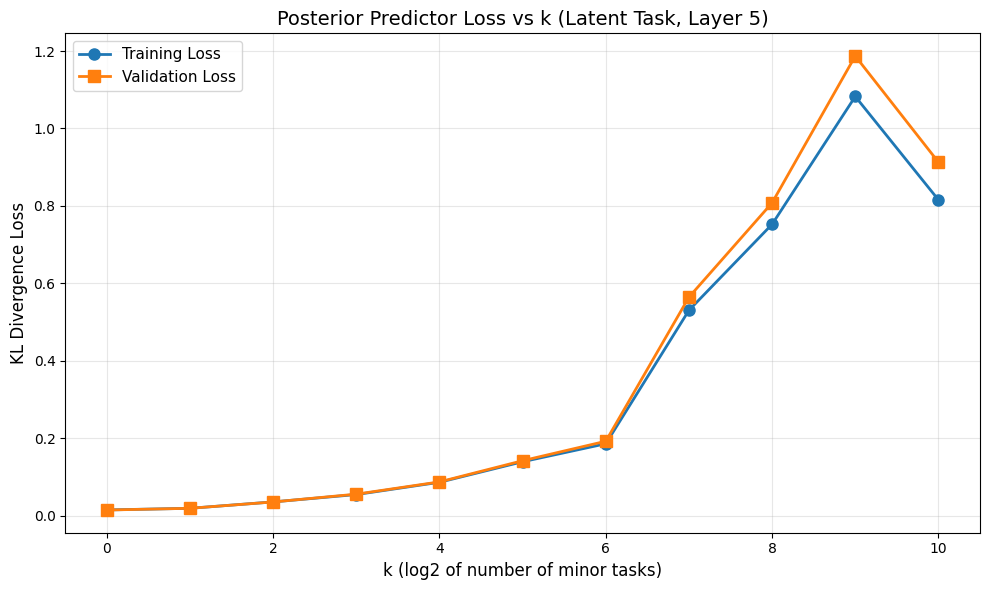

In [8]:
from icl.utils.unified_interface import (
    plot_posterior_predictor_loss_vs_k_latent,
)

# For latent task
results = plot_posterior_predictor_loss_vs_k_latent(
    k_values=range(11),
    layer=5,
    vocab_size=6,
    n_samples=4000,
    verbose=True,
    positions=range(5, 35),
    num_epochs=300, 
)

2026-02-06 20:32:38 - icl.utils.unified_interface - INFO - Computing stable ranks for logits at 11 different k values
2026-02-06 20:32:38 - icl.utils.unified_interface - INFO - Processing k=0 (n_tasks=1)...
2026-02-06 20:32:38 - icl.utils.unified_interface - INFO - Collecting logits for exp_name: train_3cbbc48ffa8b75fbc9f0bf106b881856, task_name: latent
2026-02-06 20:32:38 - icl.utils.unified_interface - INFO - Using n_minor=1 and n_ood=0
2026-02-06 20:32:38 - icl.utils.unified_interface - INFO - Computing logits using coin-style approach...
2026-02-06 20:32:39 - icl.utils.unified_interface - INFO - Retrieved logits with shape: torch.Size([4, 160, 64, 6])
2026-02-06 20:32:39 - icl.utils.unified_interface - INFO - Number of minor tasks used: 1
2026-02-06 20:32:39 - icl.utils.unified_interface - INFO - Computed stable ranks for logits with shape: torch.Size([160])
2026-02-06 20:32:39 - icl.utils.unified_interface - INFO -   k=0, n_tasks=1, max_stable_rank=1.0138
2026-02-06 20:32:39 - icl

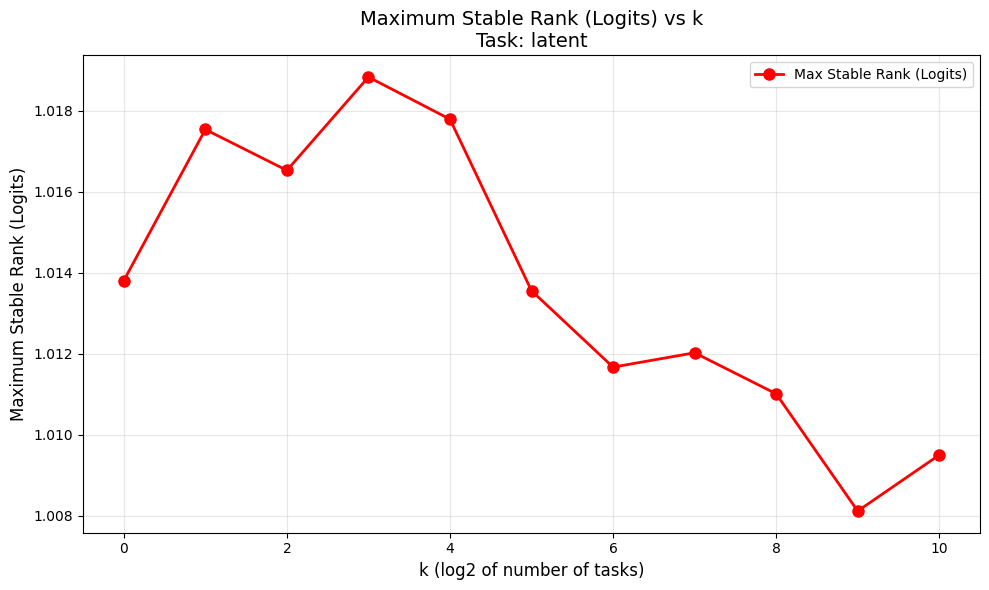

Max stable ranks: [1.013803482055664, 1.0175325870513916, 1.0165233612060547, 1.018826961517334, 1.0177857875823975, 1.0135536193847656, 1.0116674900054932, 1.012021780014038, 1.0110098123550415, 1.008116364479065, 1.0094995498657227]


In [4]:
from icl.utils.unified_interface import plot_max_stable_rank_logits_vs_k

# Plot max stable rank for logits vs k
results = plot_max_stable_rank_logits_vs_k(
    task_name="latent",
    k_values=range(11),
    vocab_size=6,
    verbose=True
)

# Access results
print(f"Max stable ranks: {results['max_stable_ranks']}")

2026-02-07 06:07:34 - icl.utils.unified_interface - INFO - Computing stable ranks of layer weights for 12 different k values
2026-02-07 06:07:34 - icl.utils.unified_interface - INFO - Number of layers: 6
2026-02-07 06:07:34 - icl.utils.unified_interface - INFO - Processing k=-1 (n_tasks=0)...
2026-02-07 06:07:34 - icl.utils.unified_interface - INFO -   k=-1, n_tasks=0, computed stable ranks for all 6 layers
2026-02-07 06:07:34 - icl.utils.unified_interface - INFO - Processing k=0 (n_tasks=1)...
2026-02-07 06:07:34 - icl.utils.unified_interface - INFO -   k=0, n_tasks=1, computed stable ranks for all 6 layers
2026-02-07 06:07:34 - icl.utils.unified_interface - INFO - Processing k=1 (n_tasks=2)...
2026-02-07 06:07:35 - icl.utils.unified_interface - INFO -   k=1, n_tasks=2, computed stable ranks for all 6 layers
2026-02-07 06:07:35 - icl.utils.unified_interface - INFO - Processing k=2 (n_tasks=4)...
2026-02-07 06:07:35 - icl.utils.unified_interface - INFO -   k=2, n_tasks=4, computed stab

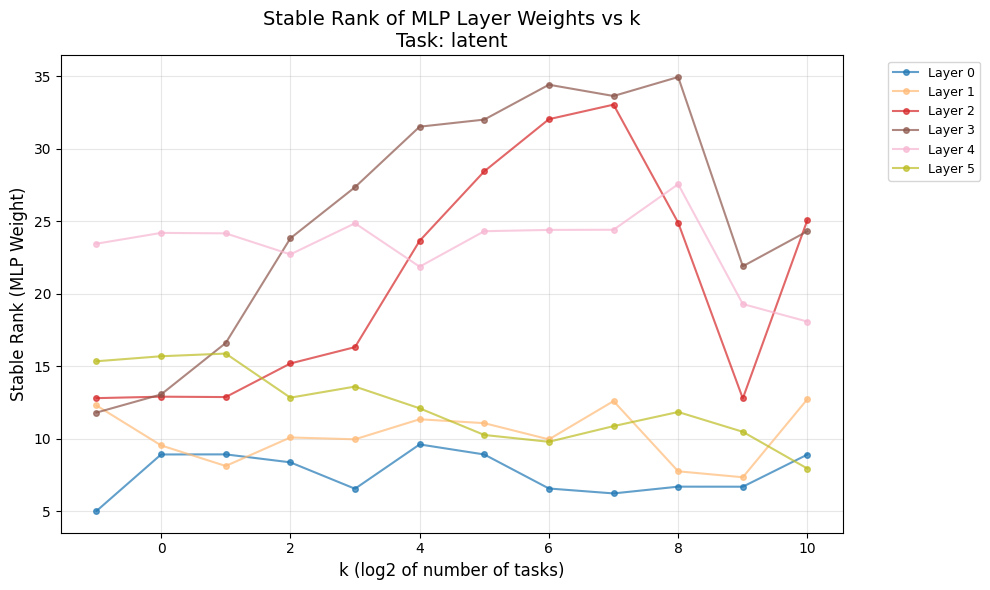

Stable ranks: {0: [np.float32(5.008846), np.float32(8.910904), np.float32(8.917158), np.float32(8.367209), np.float32(6.54585), np.float32(9.603976), np.float32(8.910911), np.float32(6.5625167), np.float32(6.22285), np.float32(6.690388), np.float32(6.6860948), np.float32(8.9056225)], 1: [np.float32(12.290541), np.float32(9.5351095), np.float32(8.116041), np.float32(10.083276), np.float32(9.957393), np.float32(11.338342), np.float32(11.07066), np.float32(9.952106), np.float32(12.593153), np.float32(7.748364), np.float32(7.338508), np.float32(12.729841)], 2: [np.float32(12.7966385), np.float32(12.897811), np.float32(12.87089), np.float32(15.188419), np.float32(16.316662), np.float32(23.649418), np.float32(28.443554), np.float32(32.040913), np.float32(33.04522), np.float32(24.900173), np.float32(12.776353), np.float32(25.0971)], 3: [np.float32(11.800033), np.float32(13.050788), np.float32(16.602411), np.float32(23.823519), np.float32(27.350777), np.float32(31.524096), np.float32(32.01331)

In [33]:
from icl.utils.unified_interface import plot_stable_rank_final_layer_weight_vs_k

# Plot stable rank of final layer weights vs k
results = plot_stable_rank_final_layer_weight_vs_k(
    task_name="latent",
    k_values=range(-1, 11),
    vocab_size=6,
    verbose=True
)

# Access results
print(f"Stable ranks: {results['stable_ranks']}")

2026-02-06 18:27:30 - icl.utils.unified_interface - INFO - Inferred task_name: latent
2026-02-06 18:27:30 - icl.utils.unified_interface - INFO - Collecting hiddens for exp_name: train_f5ec65ee483d36f73ec91c923685ecf3, task_name: latent
2026-02-06 18:27:30 - icl.utils.unified_interface - INFO - Using n_minor=1000000 and n_ood=0
2026-02-06 18:27:30 - icl.utils.unified_interface - INFO - Computing hiddens using coin-style approach...
2026-02-06 18:27:31 - icl.utils.unified_interface - INFO - Retrieved hiddens with shape: torch.Size([6, 19, 160, 64, 128])
2026-02-06 18:27:31 - icl.utils.unified_interface - INFO - Number of minor tasks used: 16
2026-02-06 18:27:49 - icl.utils.unified_interface - INFO - Computed stable ranks with shape: torch.Size([6, 160])


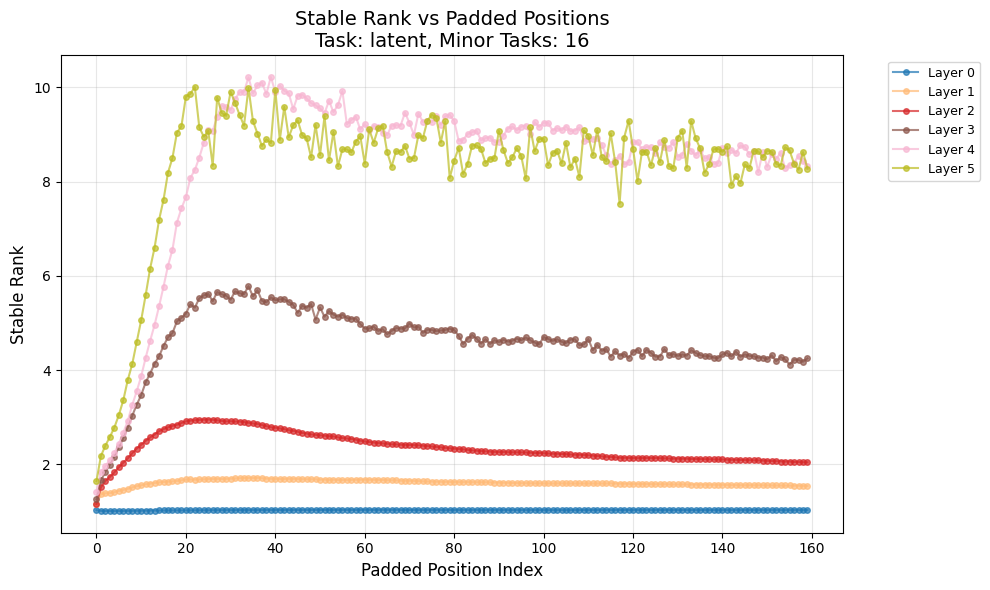

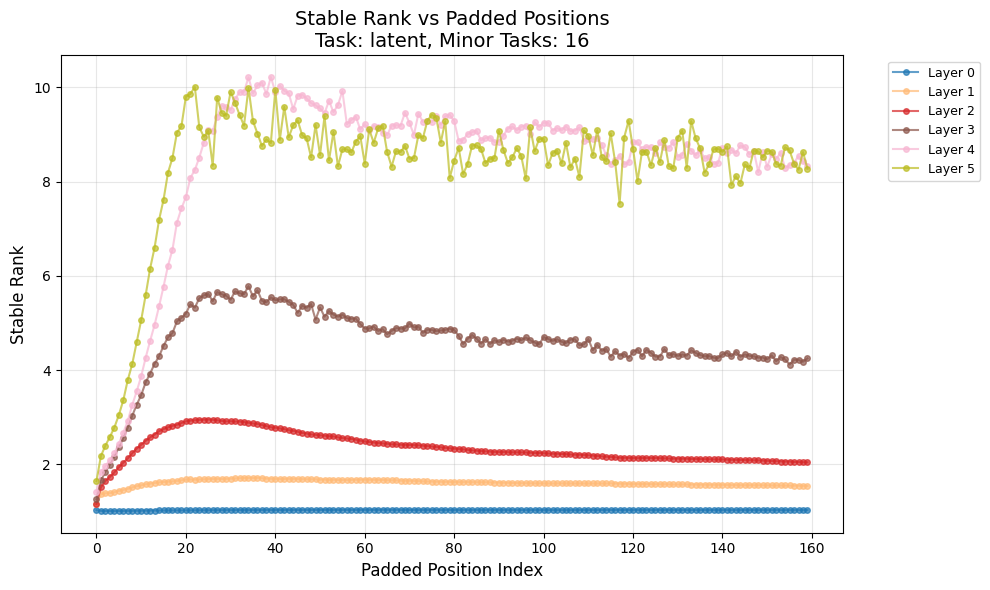

In [5]:
exp_name = get_exp_name("latent", 4, vocab_size=6)
# Simple usage - auto-detects task type
results = compute_stable_rank_at_padded_positions(
    exp_name=exp_name,
    verbose=True
)


plot_stable_rank_vs_positions(
    results=results,
    layers=None,  # Plot all layers
    average_layers=False,  # Plot individual layers
    backend="matplotlib",
    show=True
)

In [5]:
# Get experiment name
exp_name = get_exp_name("latent", 2**4, vocab_size=6)

# Get token-conditioned hiddens
all_hiddens, token_info = get_token_conditioned_hiddens_latent(
    exp_name,
    layers=[2, 4, 5],
    batch_size=64,
    n_minor=32,
    n_ood=0,
    positions_of_interest=None,
)

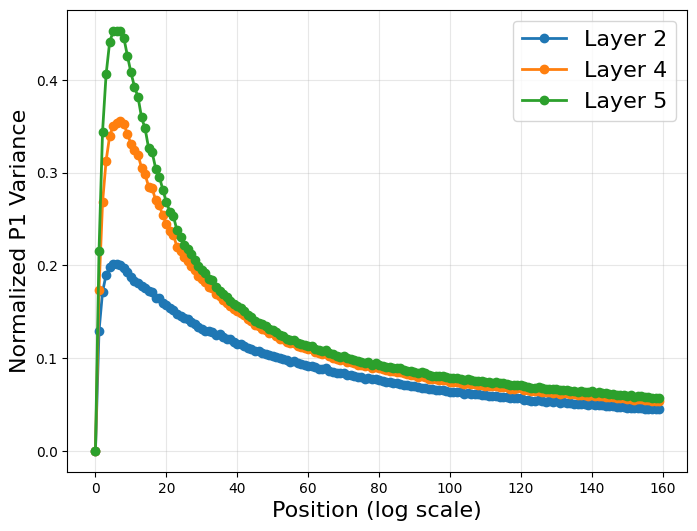

In [8]:
# Compute P1 variance (same function as linear task!)
results_dict = compute_p1_variance_multi_layer(
    all_hiddens=all_hiddens,
    token_info=token_info,
    layers=[2, 4, 5],
)

# Extract plotting data
plotting_data = extract_plotting_data_multi_layer(results_dict)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
for layer_idx in plotting_data['layers']:
    positions = plotting_data['positions']
    var_pos_norm = plotting_data['var_pos_norm'][layer_idx]
    ax.plot(positions, var_pos_norm, 'o-', label=f'Layer {layer_idx}',
            linewidth=2, markersize=6)
ax.set_xlabel('Position (log scale)', fontsize=16)
ax.set_ylabel('Normalized P1 Variance', fontsize=16)
#ax.set_xscale('log')
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
plt.show()

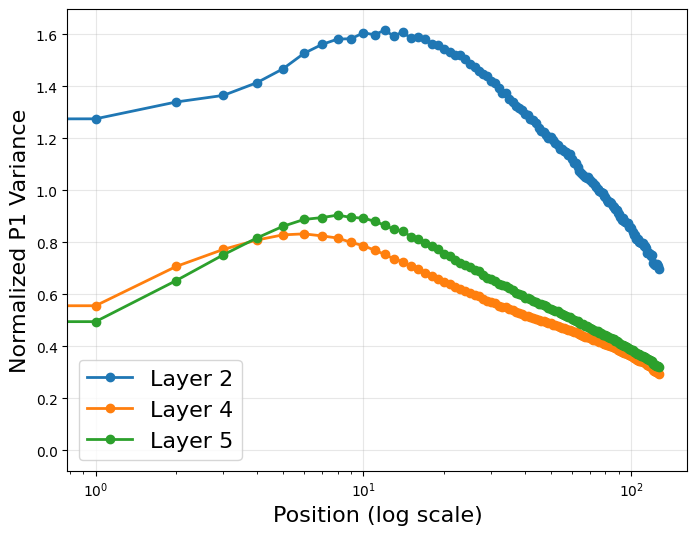

In [10]:
# Compute P1 variance (same function as linear task!)
results_dict = compute_p1_variance_multi_layer(
    all_hiddens=all_hiddens,
    token_info=token_info,
    layers=[2, 4, 5],
)

# Extract plotting data
plotting_data = extract_plotting_data_multi_layer(results_dict)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
for layer_idx in plotting_data['layers']:
    positions = plotting_data['positions']
    var_pos_norm = plotting_data['var_pos_norm'][layer_idx]
    ax.plot(positions, var_pos_norm, 'o-', label=f'Layer {layer_idx}',
            linewidth=2, markersize=6)
ax.set_xlabel('Position (log scale)', fontsize=16)
ax.set_ylabel('Normalized P1 Variance', fontsize=16)
ax.set_xscale('log')
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
plt.show()

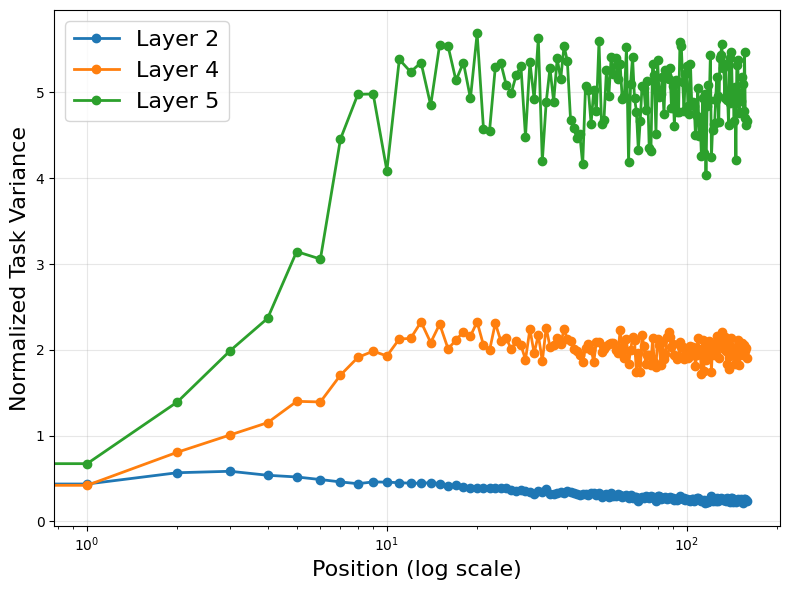

In [12]:
from icl.utils.unified_interface import get_task_variance_latent

# For latent task
exp_name = get_exp_name("latent", -1, vocab_size=6)
all_hiddens, position_info, results_dict, plotting_data = get_task_variance_latent(
    exp_name,
    layers=[2, 4, 5],
    batch_size=32,
    n_minor=0,
    n_ood=0,
)

# Plot variance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

for layer_idx in plotting_data['layers']:
    positions = plotting_data['positions']
    var_pos_norm = plotting_data['var_pos_norm'][layer_idx]
    
    ax.plot(positions, var_pos_norm, 'o-', label=f'Layer {layer_idx}', 
            linewidth=2, markersize=6)

ax.set_xlabel('Position (log scale)', fontsize=16)
ax.set_ylabel('Normalized Task Variance', fontsize=16)
ax.set_xscale('log')
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
# ax.set_ylim(0, 0.3)
plt.tight_layout()
plt.show()

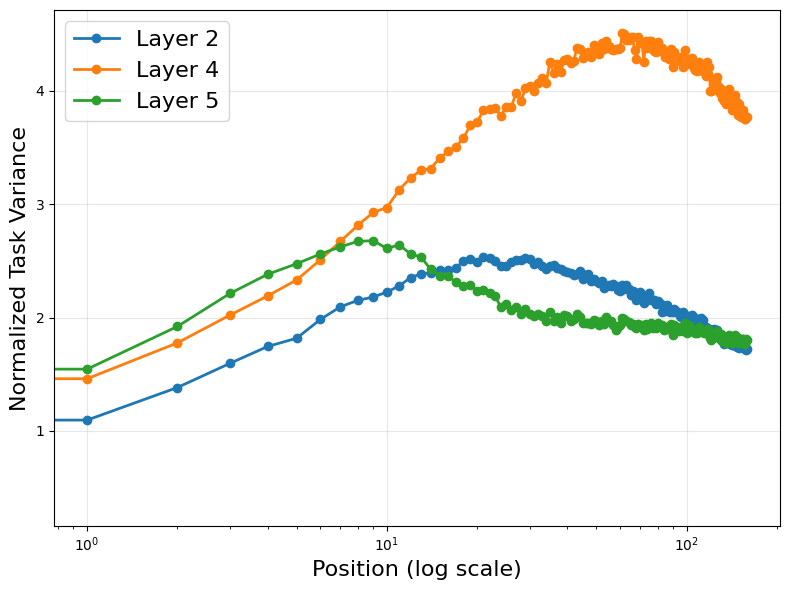

In [13]:
from icl.utils.unified_interface import get_task_variance_latent

# For latent task
exp_name = get_exp_name("latent", 10, vocab_size=6)
all_hiddens, position_info, results_dict, plotting_data = get_task_variance_latent(
    exp_name,
    layers=[2, 4, 5],
    batch_size=32,
    n_minor=32,
    n_ood=0,
)

# Plot variance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

for layer_idx in plotting_data['layers']:
    positions = plotting_data['positions']
    var_pos_norm = plotting_data['var_pos_norm'][layer_idx]
    
    ax.plot(positions, var_pos_norm, 'o-', label=f'Layer {layer_idx}', 
            linewidth=2, markersize=6)

ax.set_xlabel('Position (log scale)', fontsize=16)
ax.set_ylabel('Normalized Task Variance', fontsize=16)
ax.set_xscale('log')
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
# ax.set_ylim(0, 0.3)
plt.tight_layout()
plt.show()

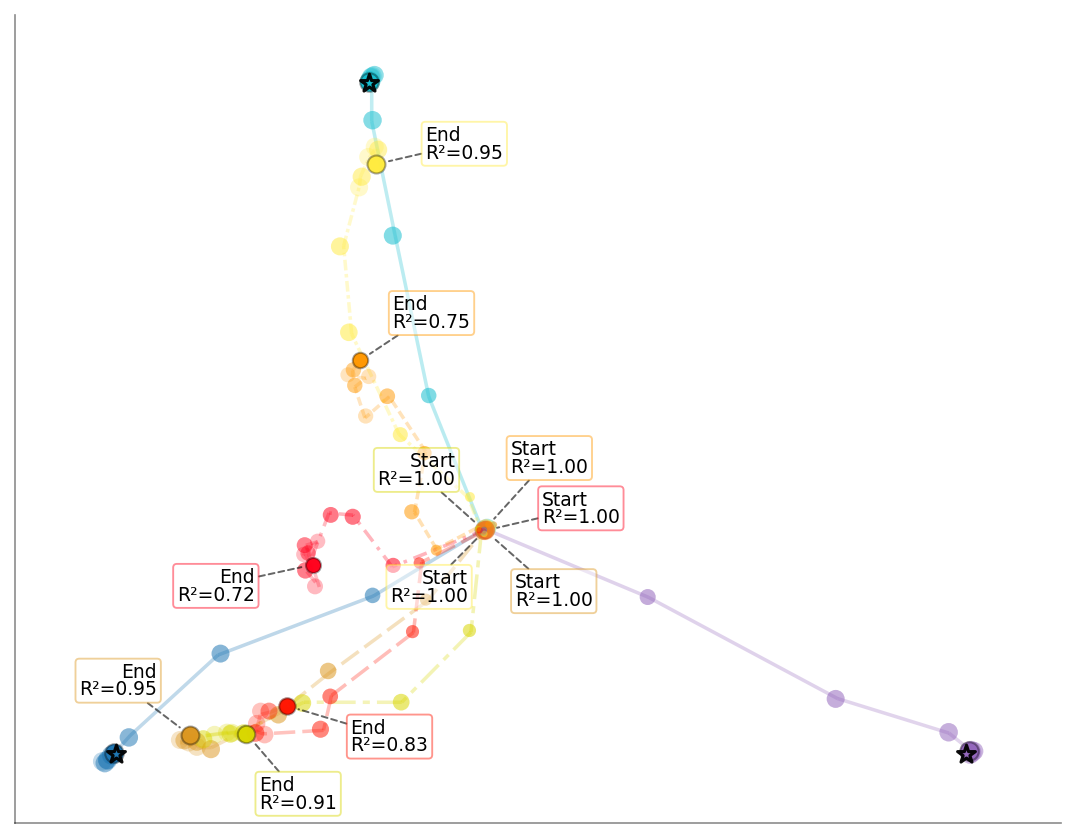

In [14]:
exp_name = get_exp_name("latent", -1, vocab_size=6)
# get_var_plot("latent", exp_name, ignore_vocab=True)
traj_projection_plot("latent", 
                     exp_name, 
                     n_minor = 0, 
                     n_ood=6, 
                     layer_index=5,
                     forced_recompute=True,
                     use_mean=True,
                     show_legend=False,
                     )

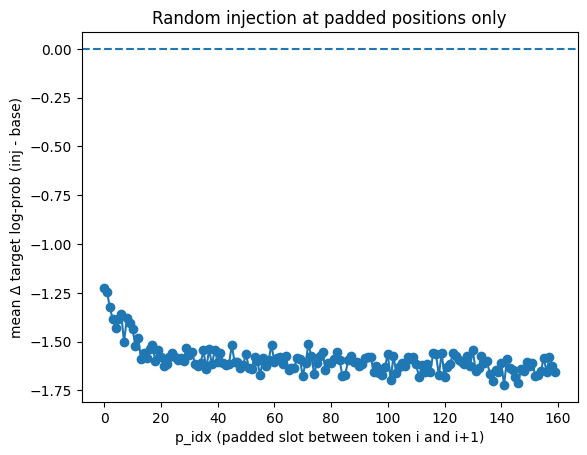

In [15]:
exp_name = get_exp_name("latent", -1, vocab_size=6)
out, _ = random_injection_latent_padded_only(exp_name, n_minor=0, n_ood=0, layer_idx=4)
plot_injection_results(out)

Computing final_task_vecs from model (using first 3 major tasks)...
Computed final_task_vecs: shape torch.Size([3, 128])
  [p_idx=0] Q.T @ h_new norm (over 35 tasks): mean=0.000002 (range: 0.000001-0.000002), max=0.000002
[latent] p_idx=00/127 (padded token_pos=001) Δlogp(mean): major=-0.0165, minor=N/A, ood=+0.0443, all=+0.0391
[latent] p_idx=05/127 (padded token_pos=011) Δlogp(mean): major=-0.1661, minor=N/A, ood=+0.2032, all=+0.1715
[latent] p_idx=10/127 (padded token_pos=021) Δlogp(mean): major=-0.2257, minor=N/A, ood=+0.2218, all=+0.1834
[latent] p_idx=15/127 (padded token_pos=031) Δlogp(mean): major=-0.2712, minor=N/A, ood=+0.2203, all=+0.1782
[latent] p_idx=20/127 (padded token_pos=041) Δlogp(mean): major=-0.2031, minor=N/A, ood=+0.2388, all=+0.2009
[latent] p_idx=25/127 (padded token_pos=051) Δlogp(mean): major=-0.2574, minor=N/A, ood=+0.2115, all=+0.1713
[latent] p_idx=30/127 (padded token_pos=061) Δlogp(mean): major=-0.2002, minor=N/A, ood=+0.1992, all=+0.1650
[latent] p_idx=

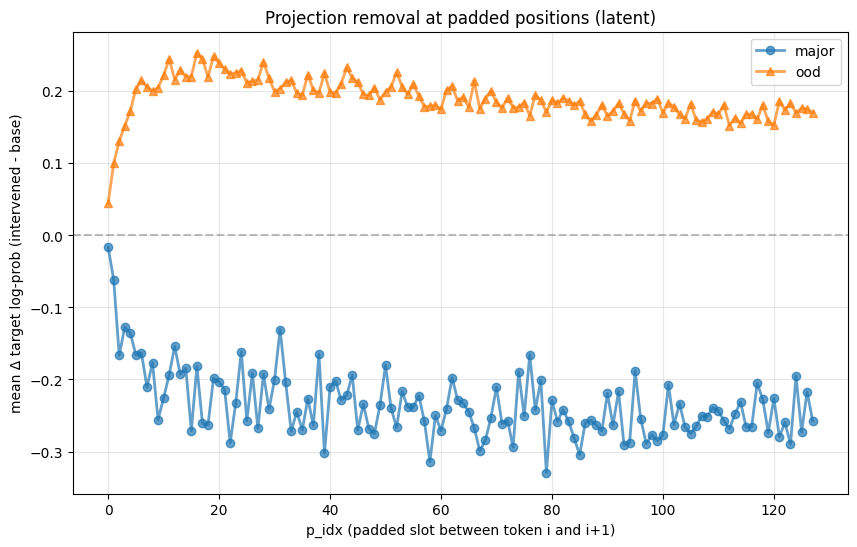

In [42]:
exp_name = get_exp_name("latent", -1, vocab_size=8)
out, info = projection_removal_latent_padded_only(
    exp_name=exp_name,
    n_major=3,        # Number of major tasks to use (default: all available)
    n_minor=0,       # Number of minor tasks
    n_ood=32,         # Number of OOD tasks
    B=96,              # Batch size
    layer_idx=3,       # Layer index for intervention
    verbose=True,      # Print progress
)
plot_projection_removal_results(out, task_name="latent", show_groups=True)

Computing final_task_vecs from model (using first 3 major tasks)...
Computed final_task_vecs: shape torch.Size([3, 128])
  [p_idx=0] Q.T @ h_new norm (over 35 tasks): mean=0.000001 (range: 0.000001-0.000001), max=0.000002
[latent] p_idx=00/127 (padded token_pos=001) Δlogp(mean): major=-0.0050, minor=N/A, ood=+0.0025, all=+0.0018
[latent] p_idx=05/127 (padded token_pos=011) Δlogp(mean): major=-0.0788, minor=N/A, ood=+0.0996, all=+0.0843
[latent] p_idx=10/127 (padded token_pos=021) Δlogp(mean): major=-0.0568, minor=N/A, ood=+0.1088, all=+0.0946
[latent] p_idx=15/127 (padded token_pos=031) Δlogp(mean): major=-0.0490, minor=N/A, ood=+0.1131, all=+0.0992
[latent] p_idx=20/127 (padded token_pos=041) Δlogp(mean): major=-0.0573, minor=N/A, ood=+0.1104, all=+0.0961
[latent] p_idx=25/127 (padded token_pos=051) Δlogp(mean): major=-0.0547, minor=N/A, ood=+0.1117, all=+0.0974
[latent] p_idx=30/127 (padded token_pos=061) Δlogp(mean): major=-0.1078, minor=N/A, ood=+0.1057, all=+0.0874
[latent] p_idx=

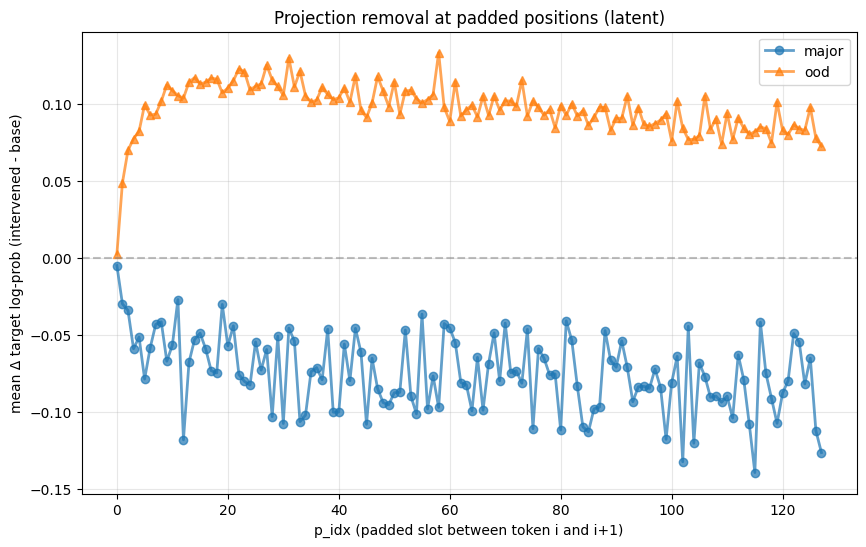

In [43]:
exp_name = get_exp_name("latent", -1, vocab_size=8)
out, info = projection_removal_latent_padded_only(
    exp_name=exp_name,
    n_major=3,        # Number of major tasks to use (default: all available)
    n_minor=0,       # Number of minor tasks
    n_ood=32,         # Number of OOD tasks
    B=96,              # Batch size
    layer_idx=4,       # Layer index for intervention
    verbose=True,      # Print progress
)
plot_projection_removal_results(out, task_name="latent", show_groups=True)

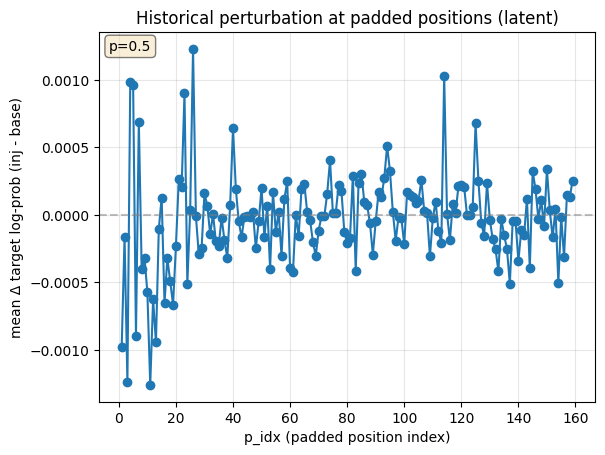

In [26]:
# For latent task
exp_name = get_exp_name("latent", -1, vocab_size=6)
out, info = historical_injection_latent(
    exp_name=exp_name, 
    n_minor=0, 
    n_ood=0,
    p=0.5,  # perturb 10% of historical positions
    layer_idx=4
)
plot_historical_injection_results(out, p=0.5, task_name="latent")

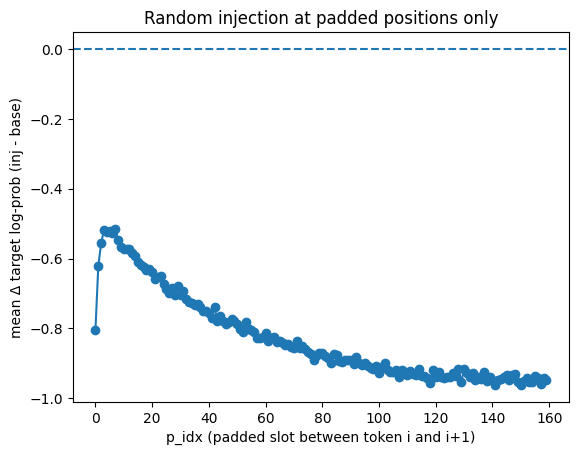

In [16]:
exp_name = get_exp_name("latent", 10, vocab_size=6)
out, _ = random_injection_latent_padded_only(exp_name, n_minor=64, n_ood=0, layer_idx=4)
plot_injection_results(out)

Computing final_task_vecs from model (using first 3 major tasks)...
Computed final_task_vecs: shape torch.Size([3, 128])
  [p_idx=0] Q.T @ h_new norm (over 67 tasks): mean=0.000001 (range: 0.000001-0.000001), max=0.000001
[latent] p_idx=00/159 (padded token_pos=001) Δlogp(mean): major=-0.0042, minor=+0.0140, ood=+0.0106, all=+0.0116
[latent] p_idx=05/159 (padded token_pos=011) Δlogp(mean): major=-0.0343, minor=+0.0721, ood=+0.0546, all=+0.0590
[latent] p_idx=10/159 (padded token_pos=021) Δlogp(mean): major=-0.0528, minor=+0.0607, ood=+0.0502, all=+0.0506
[latent] p_idx=15/159 (padded token_pos=031) Δlogp(mean): major=-0.0476, minor=+0.0414, ood=+0.0290, all=+0.0315
[latent] p_idx=20/159 (padded token_pos=041) Δlogp(mean): major=-0.0589, minor=+0.0200, ood=+0.0296, all=+0.0211
[latent] p_idx=25/159 (padded token_pos=051) Δlogp(mean): major=-0.0212, minor=+0.0224, ood=+0.0238, all=+0.0211
[latent] p_idx=30/159 (padded token_pos=061) Δlogp(mean): major=-0.0266, minor=+0.0132, ood=+0.0169,

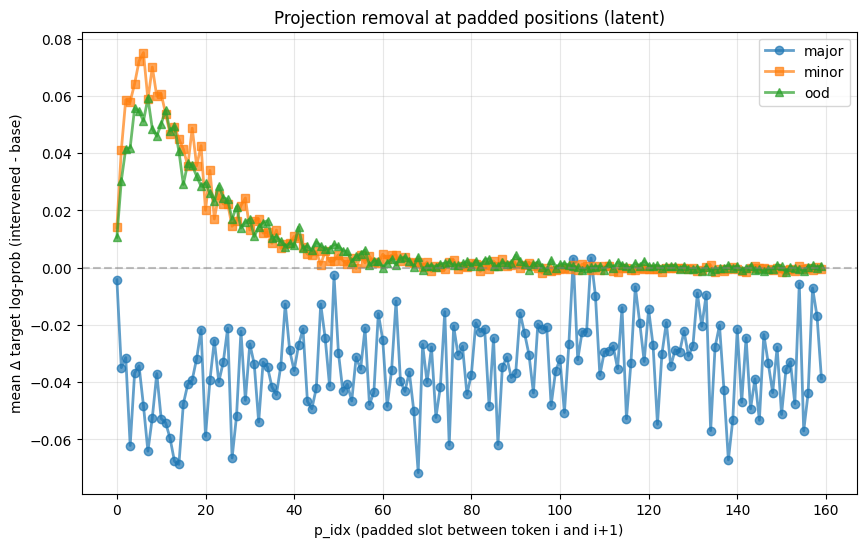

In [27]:
exp_name = get_exp_name("latent", 10, vocab_size=6)
out, info = projection_removal_latent_padded_only(
    exp_name=exp_name,
    n_major=3,        # Number of major tasks to use (default: all available)
    n_minor=32,       # Number of minor tasks
    n_ood=32,          # Number of OOD tasks
    B=96,              # Batch size
    layer_idx=3,       # Layer index for intervention
    verbose=True,      # Print progress
)
plot_projection_removal_results(out, task_name="latent", show_groups=True)

Computing final_task_vecs from model (using first 3 major tasks)...
Computed final_task_vecs: shape torch.Size([3, 128])
  [p_idx=0] Q.T @ h_new norm (over 3 tasks): mean=0.000001 (range: 0.000000-0.000001), max=0.000001
[latent] p_idx=00/159 (padded token_pos=001) Δlogp(mean): major=-0.0027, minor=N/A, ood=N/A, all=-0.0027
[latent] p_idx=05/159 (padded token_pos=011) Δlogp(mean): major=-0.0211, minor=N/A, ood=N/A, all=-0.0211
[latent] p_idx=10/159 (padded token_pos=021) Δlogp(mean): major=-0.0220, minor=N/A, ood=N/A, all=-0.0220
[latent] p_idx=15/159 (padded token_pos=031) Δlogp(mean): major=-0.0217, minor=N/A, ood=N/A, all=-0.0217
[latent] p_idx=20/159 (padded token_pos=041) Δlogp(mean): major=-0.0098, minor=N/A, ood=N/A, all=-0.0098
[latent] p_idx=25/159 (padded token_pos=051) Δlogp(mean): major=-0.0085, minor=N/A, ood=N/A, all=-0.0085
[latent] p_idx=30/159 (padded token_pos=061) Δlogp(mean): major=+0.0105, minor=N/A, ood=N/A, all=+0.0105
[latent] p_idx=35/159 (padded token_pos=071)

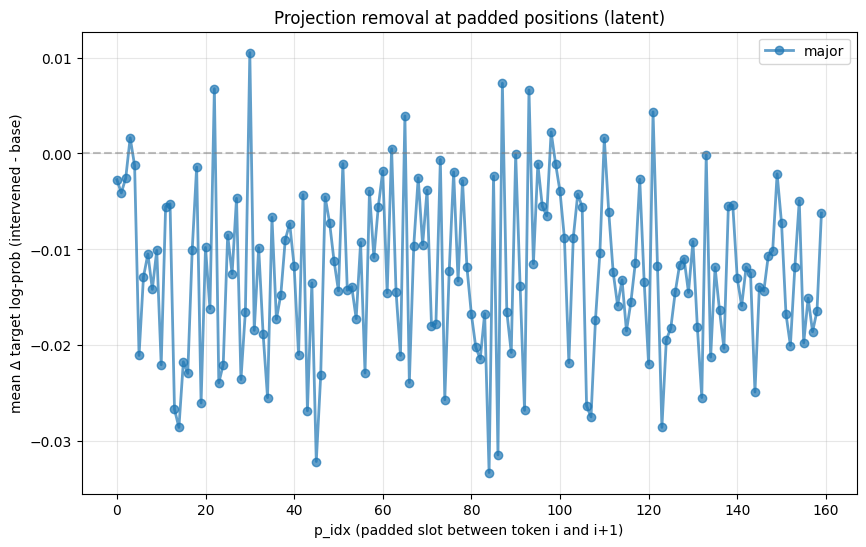

In [25]:
exp_name = get_exp_name("latent", -1, vocab_size=6)
out, info = projection_removal_latent_padded_only(
    exp_name=exp_name,
    n_major=3,        # Number of major tasks to use (default: all available)
    n_minor=0,       # Number of minor tasks
    n_ood=0,          # Number of OOD tasks
    B=96,              # Batch size
    layer_idx=5,       # Layer index for intervention
    verbose=True,      # Print progress
)
plot_projection_removal_results(out, task_name="latent", show_groups=True)


PROJECTION ONTO EXPERIMENT
Computing final_task_vecs from model (using first 3 major tasks)...
Computed final_task_vecs: shape torch.Size([3, 128])
  [p_idx=0] Q.T @ h_new norm (over 3 tasks): mean=13.857948 (range: 13.656740-13.976802), max=16.285624
[latent] p_idx=00/159 (padded token_pos=001) Δlogp(mean): major=-0.0684, minor=N/A, ood=N/A, all=-0.0684
[latent] p_idx=05/159 (padded token_pos=011) Δlogp(mean): major=-0.2991, minor=N/A, ood=N/A, all=-0.2991
[latent] p_idx=10/159 (padded token_pos=021) Δlogp(mean): major=-0.2985, minor=N/A, ood=N/A, all=-0.2985
[latent] p_idx=15/159 (padded token_pos=031) Δlogp(mean): major=-0.2836, minor=N/A, ood=N/A, all=-0.2836
[latent] p_idx=20/159 (padded token_pos=041) Δlogp(mean): major=-0.3281, minor=N/A, ood=N/A, all=-0.3281
[latent] p_idx=25/159 (padded token_pos=051) Δlogp(mean): major=-0.2409, minor=N/A, ood=N/A, all=-0.2409
[latent] p_idx=30/159 (padded token_pos=061) Δlogp(mean): major=-0.2504, minor=N/A, ood=N/A, all=-0.2504
[latent] p_i

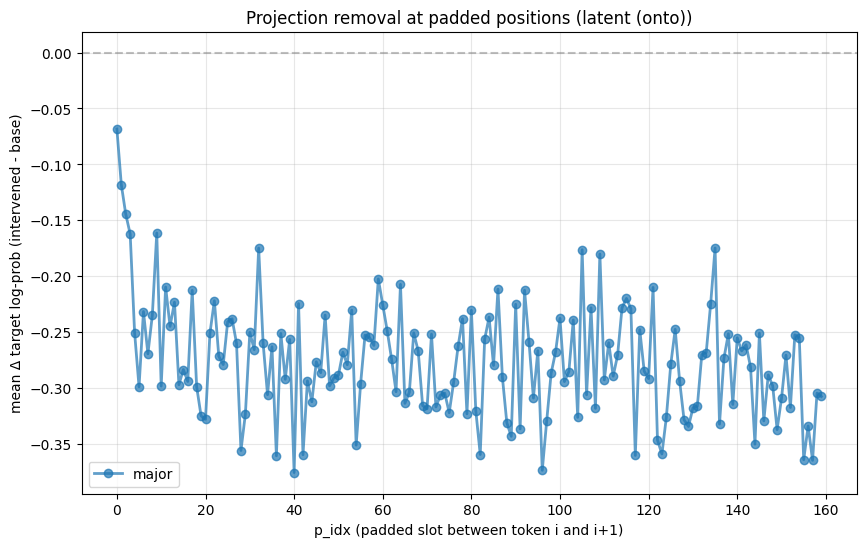

In [29]:
# Projection ONTO experiments (new functionality)
from icl.utils.projection_removal_intervention import (
    projection_onto_latent_padded_only,
    projection_removal_latent_padded_only,
    plot_projection_removal_results
)

exp_name = get_exp_name("latent", -1, vocab_size=6)

# Run projection onto experiment
print("\n" + "=" * 60)
print("PROJECTION ONTO EXPERIMENT")
print("=" * 60)
out_onto, info_onto = projection_onto_latent_padded_only(
    exp_name=exp_name,
    n_major=3,
    n_minor=0,
    n_ood=0,
    B=96,
    layer_idx=5,
    verbose=True,
    preserve_norm=True,  # Try with and without norm preservation
)
plot_projection_removal_results(out_onto, task_name="latent (onto)", show_groups=True)


In [ ]:
exp_name = get_exp_name("latent", 10, vocab_size=8)
out, info = projection_removal_latent_padded_only(
    exp_name=exp_name,
    n_major=3,        # Number of major tasks to use (default: all available)
    n_minor=32,       # Number of minor tasks
    n_ood=32,          # Number of OOD tasks
    B=96,              # Batch size
    layer_idx=5,       # Layer index for intervention
    verbose=True,      # Print progress
)
plot_projection_removal_results(out, task_name="latent", show_groups=True)

Computing final_task_vecs from model (using first 3 major tasks)...
Computed final_task_vecs: shape torch.Size([3, 128])
  [p_idx=0] Q.T @ h_new norm (over 35 tasks): mean=0.000000 (range: 0.000000-0.000000), max=0.000001
[latent] p_idx=00/127 (padded token_pos=001) Δlogp(mean): major=-0.0018, minor=+0.0034, ood=+0.0040, all=+0.0032
[latent] p_idx=05/127 (padded token_pos=011) Δlogp(mean): major=-0.0879, minor=+0.1041, ood=+0.0803, all=+0.0768
[latent] p_idx=10/127 (padded token_pos=021) Δlogp(mean): major=-0.1257, minor=+0.0655, ood=+0.0891, all=+0.0599
[latent] p_idx=15/127 (padded token_pos=031) Δlogp(mean): major=-0.1268, minor=+0.0413, ood=+0.0502, all=+0.0310
[latent] p_idx=20/127 (padded token_pos=041) Δlogp(mean): major=-0.1484, minor=+0.0205, ood=+0.0293, all=+0.0100
[latent] p_idx=25/127 (padded token_pos=051) Δlogp(mean): major=-0.0919, minor=+0.0124, ood=+0.0218, all=+0.0078
[latent] p_idx=30/127 (padded token_pos=061) Δlogp(mean): major=-0.0990, minor=+0.0066, ood=+0.0154,

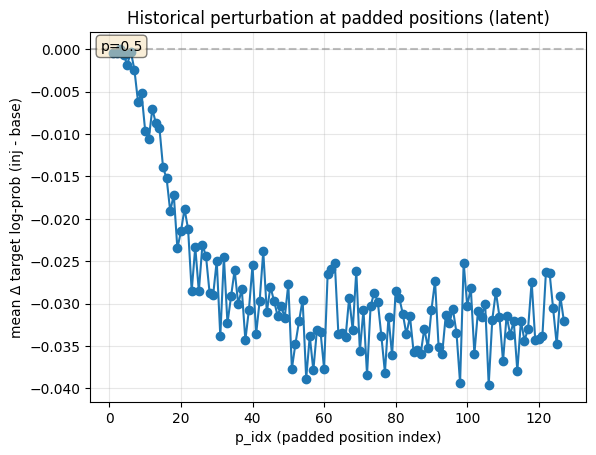

In [ ]:
# For latent task
exp_name = get_exp_name("latent", 10, vocab_size=8)
out, info = historical_injection_latent(
    exp_name=exp_name, 
    n_minor=64, 
    n_ood=0,
    p=0.5,
    layer_idx=4
)
plot_historical_injection_results(out, p=0.5, task_name="latent")

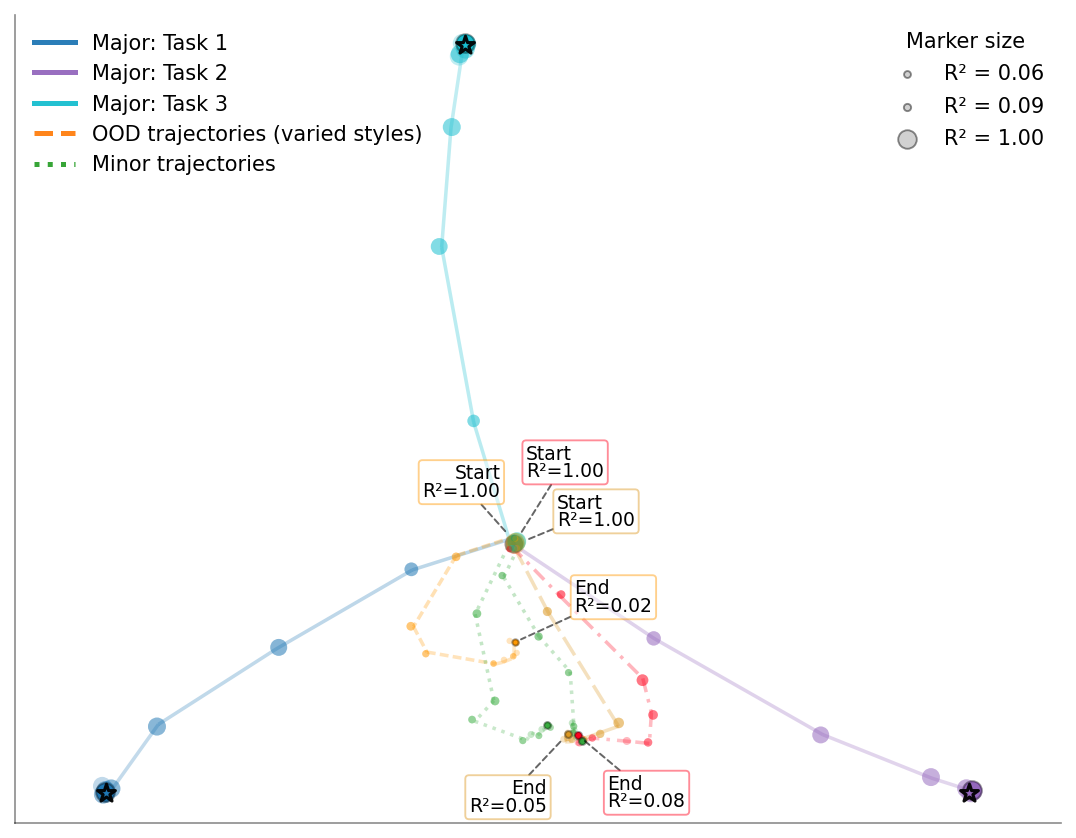

In [18]:
exp_name = get_exp_name("latent", 10, vocab_size=6)
# get_var_plot("latent", exp_name, ignore_vocab=True)
traj_projection_plot("latent", 
                     exp_name, 
                     n_minor = 2, 
                     n_ood=3, 
                     use_mean=True,
                     forced_recompute=True,
                     )

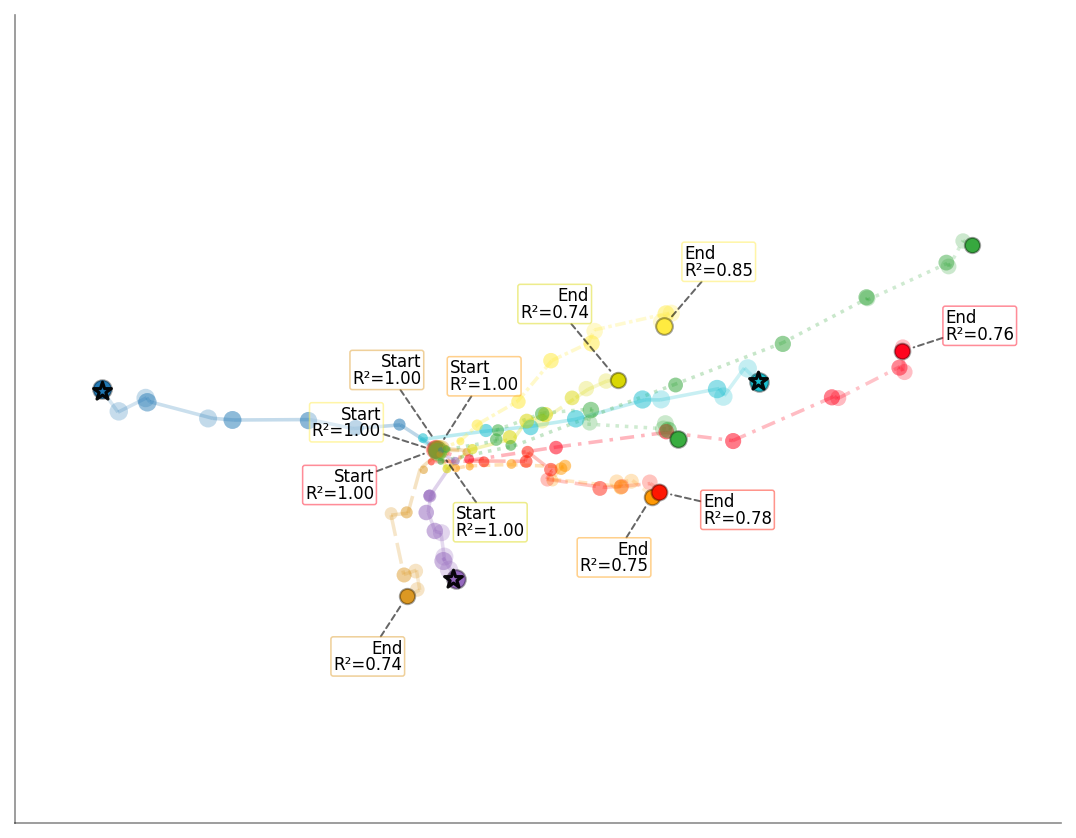

In [8]:
exp_name = get_exp_name("latent", 10, vocab_size=8)
# get_var_plot("latent", exp_name, ignore_vocab=True)
traj_projection_plot("latent", 
                     exp_name, 
                     n_minor=2, 
                     n_ood=6, 
                     use_mean=True,
                     forced_recompute=True,
                     step=2000,
                     show_legend=False,
                     )

In [19]:
steps = list(range(2000, 4001, 100))
for k in [2, 5, 10]:
    exp_name = get_exp_name("latent", k, vocab_size=6)
    results = process_ood_minor_metric(
        task_name="latent",
        exp_name=exp_name,
        steps=steps,
        force_recompute=False
    )

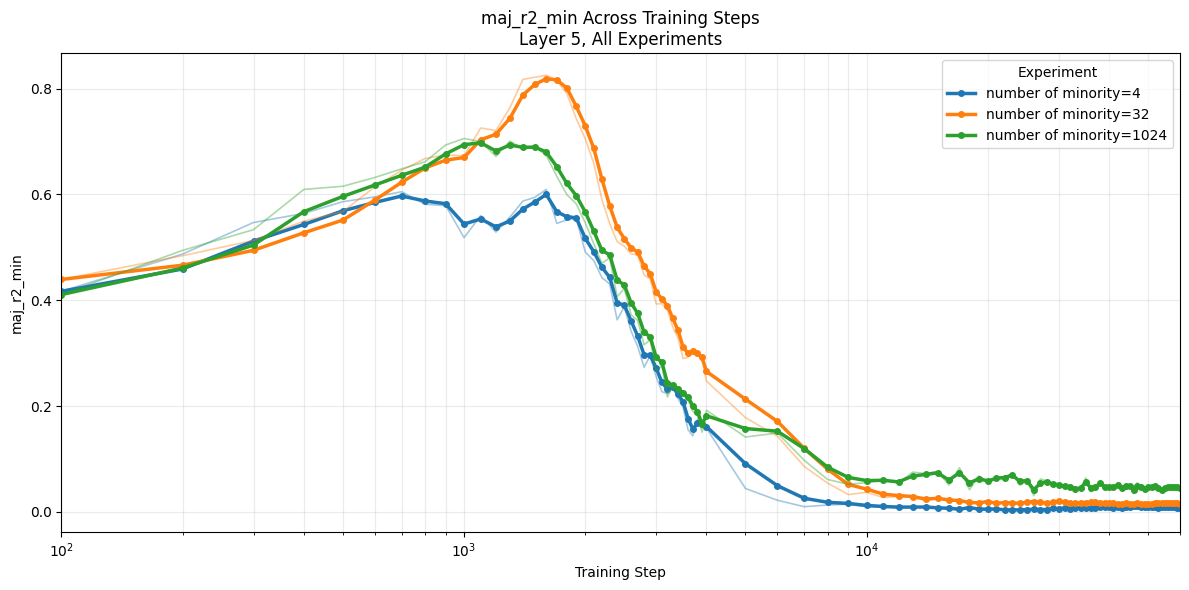

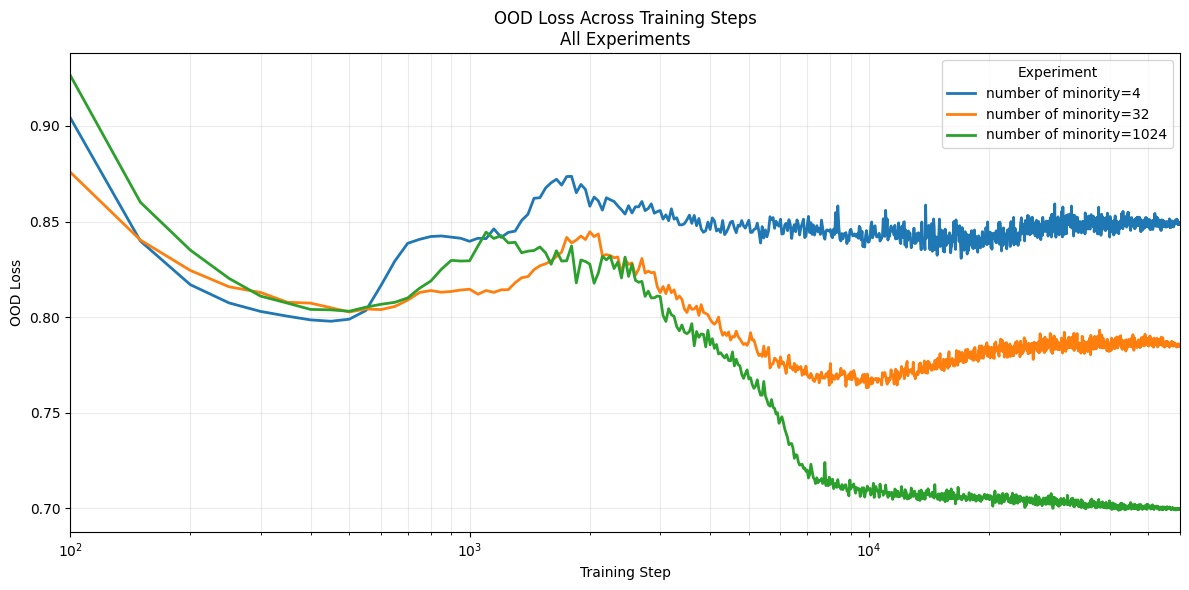

In [21]:
figs = plot_training_curves_all_experiments_mpl(
        "latent",
        list(range(100, 4000, 100)) + list(range(4000, 60001, 1000)),
        [2, 5, 10], 
        metric="maj_r2_min",
        layer_index=5,
        ema_alpha=0.6,
        vocab_size=6, 
        )

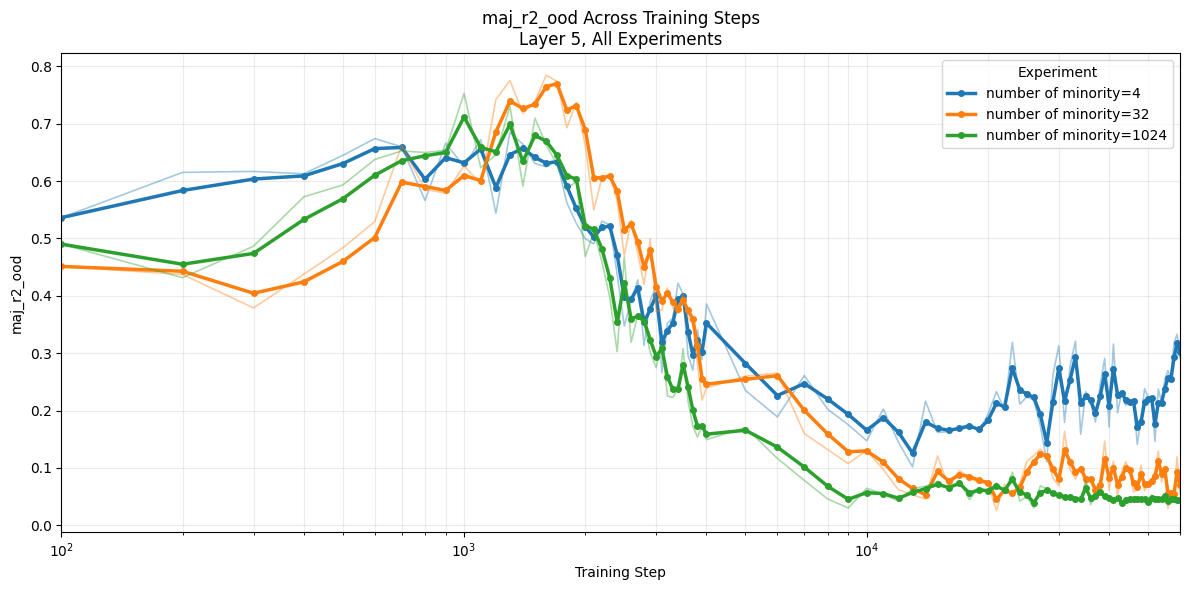

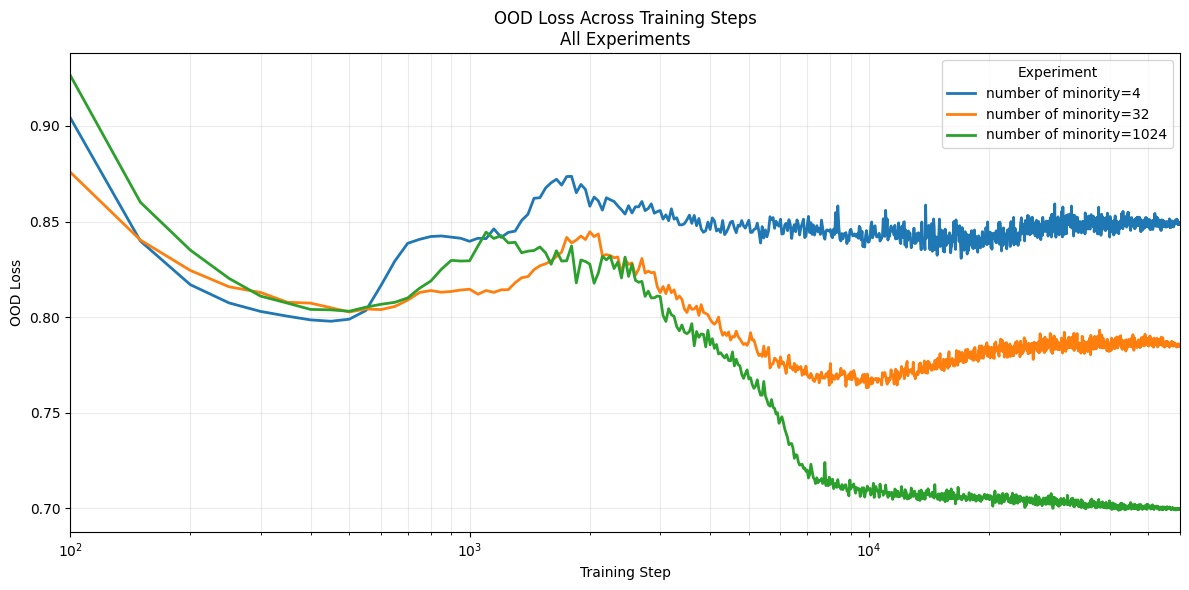

In [22]:
figs = plot_training_curves_all_experiments_mpl(
        "latent",
        list(range(100, 4000, 100)) + list(range(4000, 60001, 1000)),
        [2, 5, 10], 
        metric="maj_r2_ood",
        layer_index=5,
        ema_alpha=0.6,
        vocab_size=6,
        )

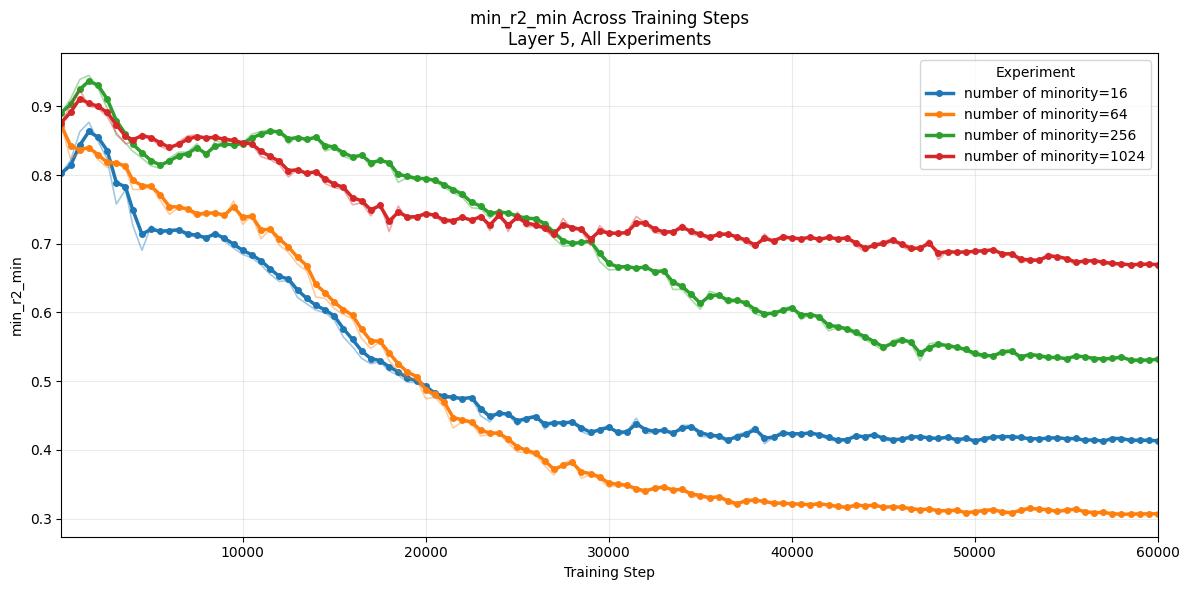

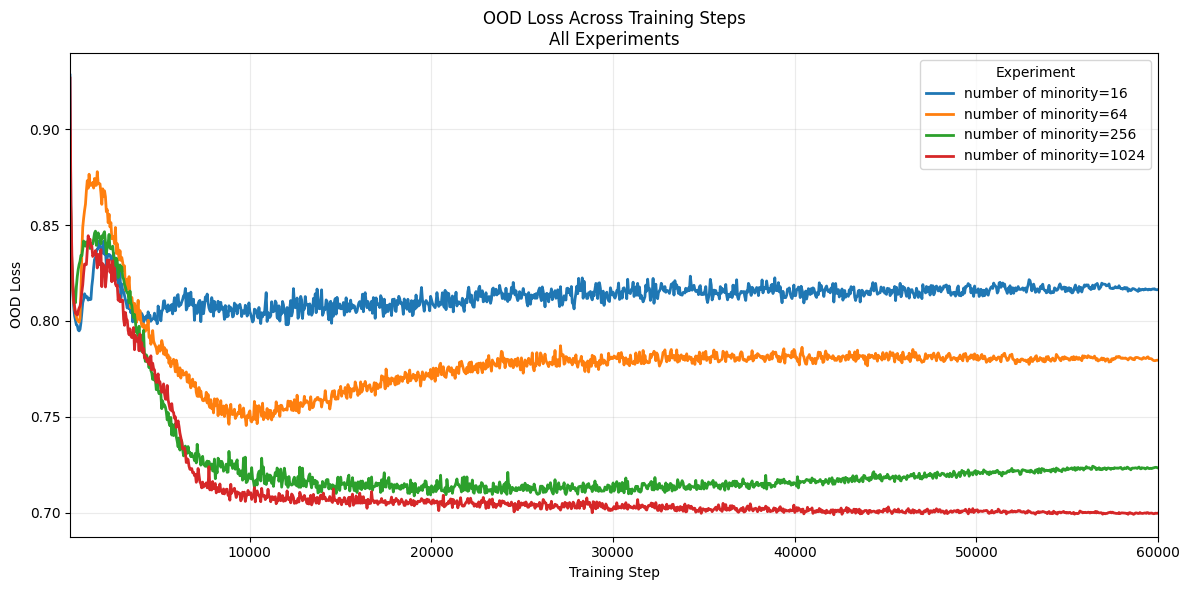

In [23]:
figs = plot_training_curves_all_experiments_mpl(
        "latent",
        list(range(100, 4000, 500)) + list(range(4000, 60001, 500)),
        [4, 6, 8, 10], 
        metric="min_r2_min",
        layer_index=5,
        ema_alpha=0.6,
        logx_first=False,
        logx_second=False,
        vocab_size=6,
        )

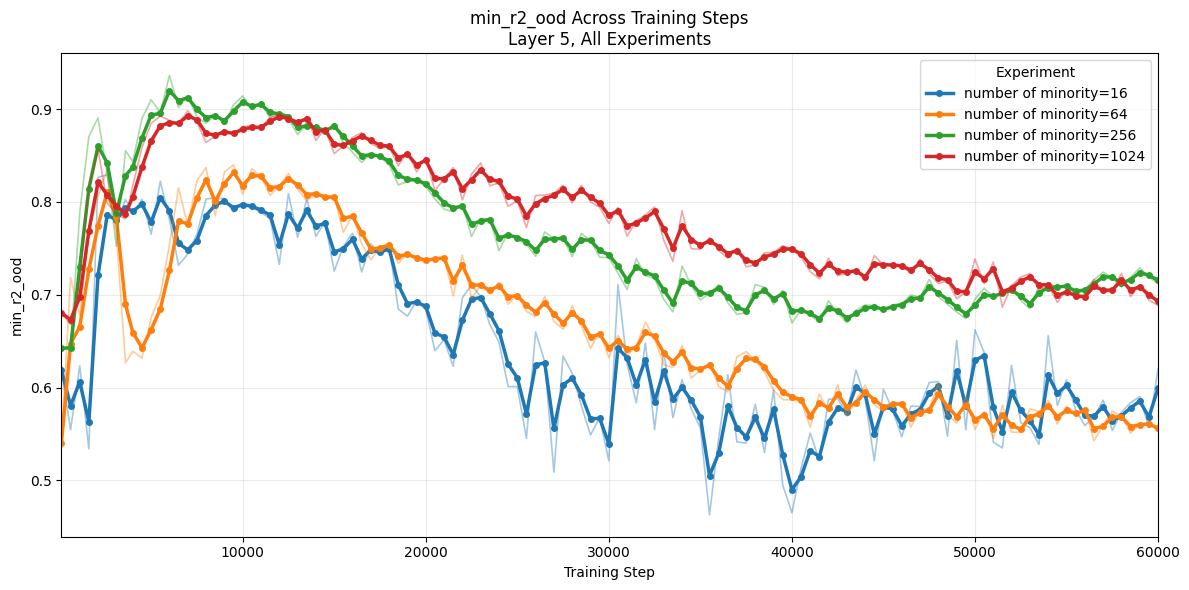

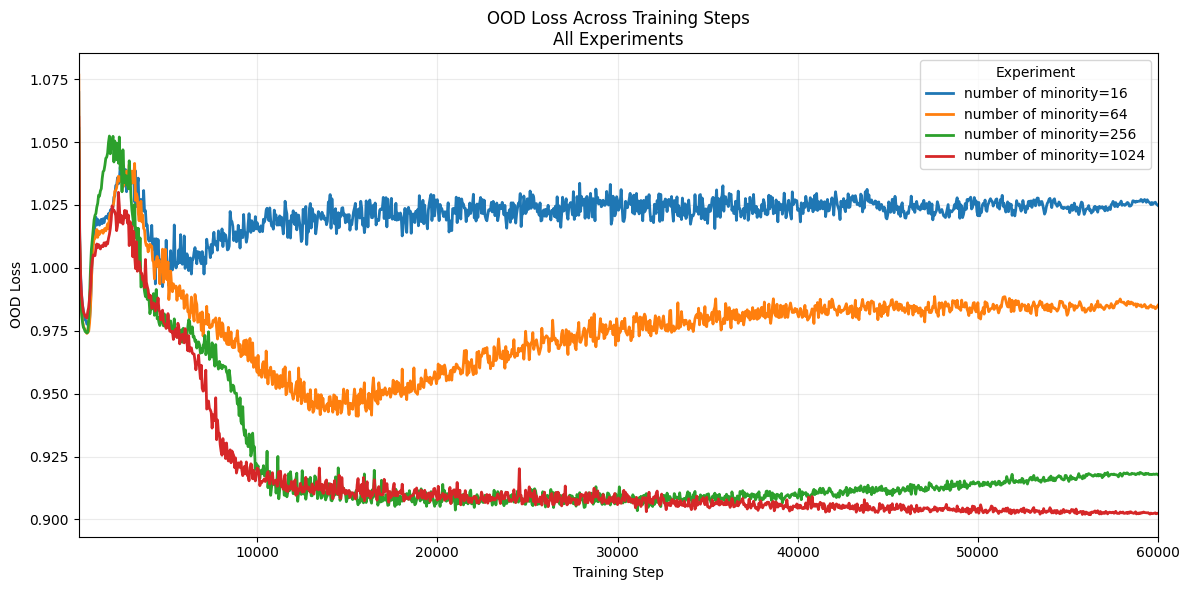

In [4]:
figs = plot_training_curves_all_experiments_mpl(
        "latent",
        list(range(100, 4000, 500)) + list(range(4000, 60001, 500)),
        [4, 6, 8, 10], 
        metric="min_r2_ood",
        layer_index=5,
        ema_alpha=0.6,
        logx_first=False,
        logx_second=False,
        )

In [ ]:
ks = list(range(1, 11))
steps = list(range(0, 60001, 500))

figs, data = plot_max_scores_over_k_steps(
    ks=ks,
    steps=steps,
    mode="ood",
    force_recompute=False,
    title_prefix="Latent",
    max_xticks=8,
    show=True,
)


attn_map, batch = get_attn_map(9, 60000)
visualize_attention_with_head_view(attn_map, batch, max_tokens=81)